<a href="https://colab.research.google.com/github/Hasibur02/ASD-Detection-Deep-Learning/blob/main/ASD_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Tue Aug 11 09:08:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


In [ ]:
import torch

device = torch.device("cuda")

print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(
    f"Memory: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB"
)

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/AutismDataset"

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Computer Science & Engineering(CSE)',
 'BCS Preparation',
 'Colab Notebooks',
 'Personal Information',
 'AutismDataset',
 'ASD_Detection_Project']

In [ ]:
dataset_path = "/content/drive/MyDrive/AutismDataset"

print(dataset_path)

/content/drive/MyDrive/AutismDataset


In [ ]:
import os

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)

    if level < 2:
        print(root)
        print("Folders:", dirs[:5])
        print("Files:", files[:5])
        print()

/content/drive/MyDrive/AutismDataset
Folders: ['test', 'consolidated', 'valid', 'train']
Files: []

/content/drive/MyDrive/AutismDataset/test
Folders: []
Files: ['Autistic.147.jpg', 'Autistic.129.jpg', 'Autistic.57.jpg', 'Autistic.139.jpg', 'Autistic.66.jpg']

/content/drive/MyDrive/AutismDataset/consolidated
Folders: ['Non_Autistic', 'Autistic']
Files: []

/content/drive/MyDrive/AutismDataset/valid
Folders: ['Autistic', 'Non_Autistic']
Files: []

/content/drive/MyDrive/AutismDataset/train
Folders: []
Files: ['Autistic.981.jpg', 'Non_Autistic.1105.jpg', 'Non_Autistic.1171.jpg', 'Non_Autistic.1123.jpg', 'Autistic.972.jpg']



In [ ]:
from pathlib import Path
import pandas as pd


def create_dataframe(folder):

    folder = Path(folder)

    data = []

    for img in folder.rglob("*"):

        if img.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue


        # Detect label from folder OR filename

        parent = img.parent.name.lower()
        filename = img.name.lower()


        if "autistic" in parent and "non" not in parent:
            label = "Autistic"

        elif "non_autistic" in parent or "non-autistic" in parent:
            label = "Non_Autistic"

        elif filename.startswith("autistic"):
            label = "Autistic"

        elif filename.startswith("non_autistic"):
            label = "Non_Autistic"

        else:
            continue


        data.append({
            "image_path": str(img),
            "label": label
        })


    return pd.DataFrame(data)

In [ ]:
dataset_path = "/content/drive/MyDrive/AutismDataset"


train_df = create_dataframe(
    f"{dataset_path}/train"
)

valid_df = create_dataframe(
    f"{dataset_path}/valid"
)

test_df = create_dataframe(
    f"{dataset_path}/test"
)

In [ ]:
for name, df in [
    ("TRAIN", train_df),
    ("VALID", valid_df),
    ("TEST", test_df)
]:

    print("="*40)
    print(name)

    if len(df) > 0:
        print(df["label"].value_counts())
    else:
        print("No images found")

TRAIN
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64
VALID
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64
TEST
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64


In [ ]:
# ==========================================================
# Imports (Google Colab + PyTorch 2.x Optimized)
# ==========================================================

import os
import glob
import time
import copy
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm


# ----------------------------
# PyTorch
# ----------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR


# ----------------------------
# AMP (PyTorch 2.x)
# ----------------------------

from torch.amp import autocast, GradScaler


# ----------------------------
# TorchVision
# ----------------------------

import torchvision
import torchvision.models as models

from torchvision import transforms

from torchvision.models import (
    vit_b_16,
    ViT_B_16_Weights,
    alexnet,
    AlexNet_Weights,
    mobilenet_v2,
    MobileNet_V2_Weights,
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights,
    regnet_y_800mf,
    RegNet_Y_800MF_Weights,
    densenet121,
    DenseNet121_Weights
)


# ----------------------------
# Sklearn
# ----------------------------

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


# ----------------------------
# Visualization
# ----------------------------

import seaborn as sns


# ----------------------------
# Settings
# ----------------------------

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


# ----------------------------
# Device Setup
# ----------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("="*60)
print("Environment Information")
print("="*60)

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Device:", device)


if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

    print(
        "GPU Memory:",
        f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB"
    )

    # Faster training for fixed image sizes
    torch.backends.cudnn.benchmark = True

else:
    print("CUDA GPU not available")


print("="*60)

Environment Information
PyTorch: 2.11.0+cpu
TorchVision: 0.26.0+cpu
Device: cpu
CUDA GPU not available


In [ ]:
# ==========================================================
# ASD Dataset Loading Cell (Google Colab Compatible)
# ==========================================================

import os
import pandas as pd


# ==========================================================
# Dataset Paths
# ==========================================================

BASE_DIR = "/content/drive/MyDrive/AutismDataset"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir  = os.path.join(BASE_DIR, "test")


# Check folders

for folder in [train_dir, valid_dir, test_dir]:

    if not os.path.exists(folder):
        raise FileNotFoundError(
            f"Directory not found: {folder}"
        )


print("✅ Dataset paths loaded successfully")
print(f"Train      : {train_dir}")
print(f"Validation : {valid_dir}")
print(f"Test       : {test_dir}")



# ==========================================================
# Read Images Function
# ==========================================================

def read_img(directory):
    """
    Load image paths and labels.

    Supports:
    1. Folder structure:
       Autistic/
       Non_Autistic/

    2. Filename structure:
       Autistic.xxx.jpg
       Non_Autistic.xxx.jpg
    """

    image_paths = []
    labels = []


    for root, dirs, files in os.walk(directory):

        for image_file in sorted(files):

            if not image_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                continue


            image_path = os.path.join(
                root,
                image_file
            )


            folder_name = os.path.basename(root).lower()
            file_name = image_file.lower()


            # Folder based labels

            if folder_name == "autistic":

                label = "Autistic"


            elif folder_name in [
                "non_autistic",
                "non-autistic"
            ]:

                label = "Non_Autistic"


            # Filename based labels

            elif file_name.startswith("autistic"):

                label = "Autistic"


            elif file_name.startswith("non_autistic"):

                label = "Non_Autistic"


            else:
                continue


            image_paths.append(image_path)
            labels.append(label)



    df = pd.DataFrame(
        {
            "image_path": image_paths,
            "label": labels
        }
    )


    print("="*50)
    print(f"Directory : {directory}")
    print(f"Images    : {len(df)}")

    if len(df) > 0:
        print(df["label"].value_counts())

    print()

    return df



# ==========================================================
# Create DataFrames
# ==========================================================

train_df = read_img(train_dir)

valid_df = read_img(valid_dir)

test_df = read_img(test_dir)



# ==========================================================
# Final Dataset Summary
# ==========================================================

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(valid_df)}")
print(f"Testing samples    : {len(test_df)}")

print()

print("Classes:")
print(train_df["label"].value_counts())

print("="*60)

✅ Dataset paths loaded successfully
Train      : /content/drive/MyDrive/AutismDataset/train
Validation : /content/drive/MyDrive/AutismDataset/valid
Test       : /content/drive/MyDrive/AutismDataset/test
Directory : /content/drive/MyDrive/AutismDataset/train
Images    : 2542
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Directory : /content/drive/MyDrive/AutismDataset/valid
Images    : 100
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Directory : /content/drive/MyDrive/AutismDataset/test
Images    : 300
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

FINAL DATASET SUMMARY
Training samples   : 2542
Validation samples : 100
Testing samples    : 300

Classes:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64


In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(valid_df)}")
print(f"Test Samples       : {len(test_df)}")


print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)


print("\nTraining Labels:")
print(train_df["label"].value_counts())


print("\nValidation Labels:")
print(valid_df["label"].value_counts())


print("\nTest Labels:")
print(test_df["label"].value_counts())



print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)


print("\nTrain:")
print(train_df.isnull().sum())


print("\nValidation:")
print(valid_df.isnull().sum())


print("\nTest:")
print(test_df.isnull().sum())



print("\n" + "=" * 60)
print("FIRST 5 TRAINING SAMPLES")
print("=" * 60)

display(train_df.head())

DATASET SUMMARY
Training Samples   : 2542
Validation Samples : 100
Test Samples       : 300

CLASS DISTRIBUTION

Training Labels:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Validation Labels:
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Test Labels:
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

MISSING VALUES

Train:
image_path    0
label         0
dtype: int64

Validation:
image_path    0
label         0
dtype: int64

Test:
image_path    0
label         0
dtype: int64

FIRST 5 TRAINING SAMPLES


,image_path,label
0,/content/drive/MyDrive/AutismDataset/train/Aut...,Autistic
1,/content/drive/MyDrive/AutismDataset/train/Aut...,Autistic
2,/content/drive/MyDrive/AutismDataset/train/Aut...,Autistic
3,/content/drive/MyDrive/AutismDataset/train/Aut...,Autistic
4,/content/drive/MyDrive/AutismDataset/train/Aut...,Autistic


In [ ]:
# ==========================================================
# Dataset Statistics
# ==========================================================

total_samples = len(train_df) + len(valid_df) + len(test_df)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Training Samples   : {len(train_df):,}")
print(f"Validation Samples : {len(valid_df):,}")
print(f"Testing Samples    : {len(test_df):,}")
print(f"Total Samples      : {total_samples:,}")


print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)


datasets = {
    "Training": train_df,
    "Validation": valid_df,
    "Testing": test_df
}


for name, df in datasets.items():

    print(f"\n{name} Set:")

    print(df["label"].value_counts())


    print("\nPercentage:")

    print(
        (df["label"]
         .value_counts(normalize=True) * 100)
        .round(2)
        .astype(str)
        + "%"
    )


print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)


print("Train:")
print(train_df.isnull().sum())


print("\nValidation:")
print(valid_df.isnull().sum())


print("\nTest:")
print(test_df.isnull().sum())


print("\n" + "=" * 60)
print("✓ Dataset loaded successfully.")
print("=" * 60)

DATASET STATISTICS
Training Samples   : 2,542
Validation Samples : 100
Testing Samples    : 300
Total Samples      : 2,942

CLASS DISTRIBUTION

Training Set:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Percentage:
label
Non_Autistic    50.04%
Autistic        49.96%
Name: proportion, dtype: object

Validation Set:
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

Testing Set:
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

MISSING VALUES
Train:
image_path    0
label         0
dtype: int64

Validation:
image_path    0
label         0
dtype: int64

Test:
image_path    0
label         0
dtype: int64

✓ Dataset loaded successfully.


In [ ]:
# ==========================================================
# Image Transformations (CNN + ViT)
# ==========================================================

from torchvision.transforms import InterpolationMode


# ==========================================================
# CNN Training Transform
# ==========================================================

train_transform_cnn = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.2,
        scale=(0.02,0.1)
    )
])



# ==========================================================
# ViT Training Transform
# ==========================================================

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.85,1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        5
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])



# ==========================================================
# Validation / Test Transform
# ==========================================================

val_test_transform_cnn = transforms.Compose([

    transforms.Resize(
        (224,224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


# ViT uses same validation preprocessing

val_test_transform_vit = val_test_transform_cnn



print("✅ All transforms created successfully")

✅ All transforms created successfully


In [ ]:
# ==========================================================
# Hyperparameters
# ==========================================================

BATCH_SIZE = 16          # ViT-B/16 on Tesla T4
NUM_WORKERS = 2          # Colab recommended
LEARNING_RATE = 3e-5
NUM_EPOCHS = 25
WEIGHT_DECAY = 0.05

PIN_MEMORY = torch.cuda.is_available()



# ==========================================================
# Dataset Class
# ==========================================================

class AutismDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        label_encoder=None,
        fit_label_encoder=False
    ):

        self.data = dataframe.reset_index(drop=True)

        self.transform = transform

        self.image_paths = self.data["image_path"].values


        # Label encoding

        if label_encoder is None:

            self.label_encoder = LabelEncoder()

            if fit_label_encoder:

                self.labels = self.label_encoder.fit_transform(
                    self.data["label"]
                )

            else:
                raise ValueError(
                    "Set fit_label_encoder=True for training dataset"
                )

        else:

            self.label_encoder = label_encoder

            self.labels = self.label_encoder.transform(
                self.data["label"]
            )


    def __len__(self):

        return len(self.data)



    def __getitem__(self, idx):

        image_path = self.image_paths[idx]


        try:

            image = Image.open(
                image_path
            ).convert("RGB")


        except Exception as e:

            print("Error loading:", image_path)

            image = Image.new(
                "RGB",
                (224,224),
                "black"
            )


        if self.transform:

            image = self.transform(image)



        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        return image, label



    def get_label_encoder(self):

        return self.label_encoder



    def get_class_names(self):

        return self.label_encoder.classes_





# ==========================================================
# DataLoader Function
# ==========================================================

def create_dataloaders(
    train_df,
    val_df,
    test_df,
    train_transform,
    val_test_transform,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
):


    # Training dataset

    train_dataset = AutismDataset(
        train_df,
        transform=train_transform,
        fit_label_encoder=True
    )


    label_encoder = train_dataset.get_label_encoder()



    # Validation dataset

    val_dataset = AutismDataset(
        val_df,
        transform=val_test_transform,
        label_encoder=label_encoder
    )


    # Test dataset

    test_dataset = AutismDataset(
        test_df,
        transform=val_test_transform,
        label_encoder=label_encoder
    )



    loader_args = {

        "batch_size": batch_size,

        "num_workers": num_workers,

        "pin_memory": PIN_MEMORY

    }



    if num_workers > 0:

        loader_args["persistent_workers"] = True

        loader_args["prefetch_factor"] = 2



    train_loader = DataLoader(

        train_dataset,

        shuffle=True,

        drop_last=True,

        **loader_args

    )



    val_loader = DataLoader(

        val_dataset,

        shuffle=False,

        **loader_args

    )



    test_loader = DataLoader(

        test_dataset,

        shuffle=False,

        **loader_args

    )



    print("="*60)
    print("DATALOADER SUMMARY")
    print("="*60)

    print(f"Training Images   : {len(train_dataset):,}")
    print(f"Validation Images : {len(val_dataset):,}")
    print(f"Testing Images    : {len(test_dataset):,}")

    print()

    print(f"Batch Size        : {batch_size}")
    print(f"Workers           : {num_workers}")
    print(f"Pin Memory        : {PIN_MEMORY}")

    print()

    print("Classes:")
    print(label_encoder.classes_)

    print("="*60)



    return (
        train_loader,
        val_loader,
        test_loader,
        label_encoder
    )

In [ ]:
def train_model(
    self,
    num_epochs=25,
    lr=3e-5,
    weight_decay=0.05,
    save_best=True,
    model_name="model"
):

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )


    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, self.model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )


    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )


    # PyTorch 2.x AMP
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available()
    )


    best_val_acc = 0.0

    best_model_wts = copy.deepcopy(
        self.model.state_dict()
    )


    patience = 7
    patience_counter = 0


    print(f"Starting training for {num_epochs} epochs...")
    print("-"*60)


    start_time = time.time()



    for epoch in range(num_epochs):


        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-"*60)



        # ==================================================
        # Freeze ViT backbone first 5 epochs
        # ==================================================

        if hasattr(self.model, "heads"):


            if epoch == 0:

                print("Freezing ViT backbone...")


                for param in self.model.parameters():

                    param.requires_grad = False


                for param in self.model.heads.parameters():

                    param.requires_grad = True



            elif epoch == 5:

                print("Unfreezing ViT backbone...")


                for param in self.model.parameters():

                    param.requires_grad = True



        # ==================================================
        # Train / Validation
        # ==================================================

        for phase in ["train","val"]:


            if phase == "train":

                self.model.train()

                dataloader = self.train_loader


            else:

                self.model.eval()

                dataloader = self.val_loader



            running_loss = 0.0

            running_corrects = 0

            total_samples = 0



            pbar = tqdm(
                dataloader,
                desc=phase.upper(),
                leave=False
            )



            for inputs, labels in pbar:


                inputs = inputs.to(
                    self.device,
                    non_blocking=True
                )

                labels = labels.to(
                    self.device,
                    non_blocking=True
                )


                optimizer.zero_grad(
                    set_to_none=True
                )



                with torch.set_grad_enabled(
                    phase=="train"
                ):


                    with torch.amp.autocast(
                        device_type="cuda",
                        enabled=torch.cuda.is_available()
                    ):


                        outputs = self.model(inputs)


                        loss = criterion(
                            outputs,
                            labels
                        )



                    _, preds = torch.max(
                        outputs,
                        1
                    )



                    if phase=="train":


                        scaler.scale(
                            loss
                        ).backward()



                        torch.nn.utils.clip_grad_norm_(
                            self.model.parameters(),
                            max_norm=1.0
                        )



                        scaler.step(
                            optimizer
                        )

                        scaler.update()



                running_loss += (
                    loss.item()
                    *
                    inputs.size(0)
                )


                running_corrects += (
                    preds == labels
                ).sum().item()


                total_samples += labels.size(0)



                pbar.set_postfix(
                    Loss=f"{running_loss/total_samples:.4f}",
                    Acc=f"{running_corrects/total_samples:.4f}"
                )




            epoch_loss = running_loss / total_samples

            epoch_acc = running_corrects / total_samples



            print(
                f"{phase.capitalize()} "
                f"Loss: {epoch_loss:.4f} "
                f"Acc: {epoch_acc:.4f}"
            )



            if phase=="train":

                self.train_losses.append(
                    epoch_loss
                )

                self.train_accuracies.append(
                    epoch_acc
                )



            else:


                self.val_losses.append(
                    epoch_loss
                )

                self.val_accuracies.append(
                    epoch_acc
                )



                # Save best model

                if epoch_acc > best_val_acc:


                    best_val_acc = epoch_acc


                    best_model_wts = copy.deepcopy(
                        self.model.state_dict()
                    )


                    patience_counter = 0



                    if save_best:


                        torch.save(
                            {
                            "epoch":epoch+1,

                            "model_state_dict":
                                self.model.state_dict(),

                            "optimizer_state_dict":
                                optimizer.state_dict(),

                            "scheduler_state_dict":
                                scheduler.state_dict(),

                            "best_val_acc":
                                best_val_acc

                            },

                            f"best_{model_name}.pth"
                        )



                        print(
                            f"✓ Best model saved "
                            f"(Val Acc: {best_val_acc:.4f})"
                        )



                else:

                    patience_counter += 1




        # Scheduler update

        scheduler.step()


        current_lr = scheduler.get_last_lr()[0]


        print(
            f"Learning Rate: {current_lr:.2e}"
        )



        if patience_counter >= patience:


            print(
                f"\nEarly stopping at epoch {epoch+1}"
            )

            break




    elapsed = time.time() - start_time



    print("\n" + "="*60)

    print(
        f"Training complete: "
        f"{elapsed//60:.0f}m "
        f"{elapsed%60:.0f}s"
    )


    print(
        f"Best Validation Accuracy: "
        f"{best_val_acc:.4f}"
    )

    print("="*60)



    self.model.load_state_dict(
        best_model_wts
    )


    return self.model

In [ ]:

# ==========================================================
# Model Factory Functions (PyTorch 2.x + Colab Optimized)
# ==========================================================

from torchvision.models import (

    vit_b_16, ViT_B_16_Weights,

    alexnet, AlexNet_Weights,

    mobilenet_v2, MobileNet_V2_Weights,

    mobilenet_v3_large,
    MobileNet_V3_Large_Weights,

    regnet_y_800mf,
    RegNet_Y_800MF_Weights,

    densenet121,
    DenseNet121_Weights

)



# ==========================================================
# Vision Transformer ViT-B/16
# ==========================================================

def create_vit_model(
    architecture="vit_b_16",
    num_classes=2,
    pretrained=True
):

    if architecture == "vit_b_16":

        weights = (
            ViT_B_16_Weights.DEFAULT
            if pretrained else None
        )

        model = vit_b_16(
            weights=weights
        )


    else:

        raise ValueError(
            "Only vit_b_16 supported"
        )


    in_features = model.heads.head.in_features


    model.heads.head = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model



# ==========================================================
# AlexNet
# ==========================================================

def create_alexnet_model(
    num_classes=2,
    pretrained=True
):

    weights = (
        AlexNet_Weights.DEFAULT
        if pretrained else None
    )


    model = alexnet(
        weights=weights
    )


    in_features = (
        model.classifier[6]
        .in_features
    )


    model.classifier[6] = nn.Sequential(

        nn.Dropout(0.5),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# MobileNetV2
# ==========================================================

def create_mobilenet_model(
    version="v2",
    num_classes=2,
    pretrained=True
):


    if version == "v2":


        weights = (
            MobileNet_V2_Weights.DEFAULT
            if pretrained else None
        )


        model = mobilenet_v2(
            weights=weights
        )


        in_features = (
            model.classifier[1]
            .in_features
        )


        model.classifier[1] = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                in_features,
                num_classes
            )
        )



    elif version == "v3_large":


        weights = (
            MobileNet_V3_Large_Weights.DEFAULT
            if pretrained else None
        )


        model = mobilenet_v3_large(
            weights=weights
        )


        in_features = (
            model.classifier[3]
            .in_features
        )


        model.classifier[3] = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                in_features,
                num_classes
            )
        )


    else:

        raise ValueError(
            "Use v2 or v3_large"
        )


    return model




# ==========================================================
# RegNetY-800MF
# ==========================================================

def create_regnet_model(
    num_classes=2,
    pretrained=True
):


    weights = (

        RegNet_Y_800MF_Weights.DEFAULT

        if pretrained else None

    )


    model = regnet_y_800mf(
        weights=weights
    )


    in_features = model.fc.in_features


    model.fc = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# DenseNet121
# ==========================================================

def create_densenet_model(
    num_classes=2,
    pretrained=True
):


    weights = (

        DenseNet121_Weights.DEFAULT

        if pretrained else None

    )


    model = densenet121(
        weights=weights
    )


    in_features = (
        model.classifier.in_features
    )


    model.classifier = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# Model Test Function
# ==========================================================

def check_model(model):

    model = model.to(device)

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )


    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    print("="*50)

    print(
        f"Model: {model.__class__.__name__}"
    )

    print(
        f"Total Parameters: "
        f"{total_params/1e6:.2f}M"
    )

    print(
        f"Trainable Parameters: "
        f"{trainable_params/1e6:.2f}M"
    )

    print("="*50)

    return model

In [ ]:
# ==========================================================
# Device Configuration (Colab + Tesla T4 Optimized)
# ==========================================================

import torch


# Select device

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("="*60)
print("DEVICE CONFIGURATION")
print("="*60)


print(f"Using device: {device}")



if torch.cuda.is_available():


    gpu_name = torch.cuda.get_device_name(0)


    gpu_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory / 1024**3
    )


    allocated = (
        torch.cuda.memory_allocated(0)
        / 1024**3
    )


    reserved = (
        torch.cuda.memory_reserved(0)
        / 1024**3
    )


    print(f"GPU Name        : {gpu_name}")
    print(f"GPU Memory      : {gpu_memory:.1f} GB")

    print()

    print(f"CUDA Version    : {torch.version.cuda}")
    print(f"PyTorch Version : {torch.__version__}")

    print()

    print(f"Allocated GPU Memory : {allocated:.2f} GB")
    print(f"Reserved GPU Memory  : {reserved:.2f} GB")



    # Faster training
    torch.backends.cudnn.benchmark = True


    # TensorFloat32 acceleration (Tesla T4 supports it)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True



    print()

    print("✅ CUDA acceleration enabled")
    print("✅ cuDNN benchmark enabled")
    print("✅ TF32 enabled")



else:


    print("⚠ CUDA GPU not available")
    print("Training will run on CPU")



print("="*60)

DEVICE CONFIGURATION
Using device: cpu
⚠ CUDA GPU not available
Training will run on CPU


In [ ]:
# ==========================================================
# Create CNN DataLoaders (Colab Optimized)
# ==========================================================

train_loader_cnn, val_loader_cnn, test_loader_cnn, label_encoder = create_dataloaders(

    train_df,
    valid_df,
    test_df,

    train_transform_cnn,
    val_test_transform_cnn,

    batch_size=32,
    num_workers=2
)



print("="*60)
print("CNN DataLoaders Created")
print("="*60)


print(f"Training samples   : {len(train_loader_cnn.dataset):,}")
print(f"Validation samples : {len(val_loader_cnn.dataset):,}")
print(f"Test samples       : {len(test_loader_cnn.dataset):,}")


print()


print(f"Training batches   : {len(train_loader_cnn):,}")
print(f"Validation batches : {len(val_loader_cnn):,}")
print(f"Test batches       : {len(test_loader_cnn):,}")


print()


print(f"Classes             : {list(label_encoder.classes_)}")
print(f"Number of classes   : {len(label_encoder.classes_)}")



# ==========================================================
# Check one batch
# ==========================================================

images, labels = next(iter(train_loader_cnn))


print("\nBatch Verification")
print("="*60)

print(f"Image batch shape : {images.shape}")
print(f"Label shape       : {labels.shape}")

print("="*60)

DATALOADER SUMMARY
Training Images   : 2,542
Validation Images : 100
Testing Images    : 300

Batch Size        : 32
Workers           : 2
Pin Memory        : False

Classes:
['Autistic' 'Non_Autistic']
CNN DataLoaders Created
Training samples   : 2,542
Validation samples : 100
Test samples       : 300

Training batches   : 79
Validation batches : 4
Test batches       : 10

Classes             : ['Autistic', 'Non_Autistic']
Number of classes   : 2

Batch Verification
Image batch shape : torch.Size([32, 3, 224, 224])
Label shape       : torch.Size([32])


In [ ]:
# ==========================================================
# ViT-B/16 Transforms (Colab Optimized)
# ==========================================================

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ----------------------------
# Training Transform
# ----------------------------

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),


    transforms.RandomHorizontalFlip(
        p=0.5
    ),


    transforms.RandomRotation(
        degrees=5
    ),


    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),


    transforms.ToTensor(),


    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])



# ----------------------------
# Validation / Test Transform
# ----------------------------

val_test_transform_vit = transforms.Compose([

    transforms.Resize(
        (224,224),
        interpolation=InterpolationMode.BICUBIC
    ),


    transforms.ToTensor(),


    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])



print("✅ ViT-B/16 transforms created")

✅ ViT-B/16 transforms created


In [ ]:
# ==========================================================
# Create ViT DataLoaders (Colab Tesla T4 Optimized)
# ==========================================================

train_loader_vit, val_loader_vit, test_loader_vit, vit_label_encoder = create_dataloaders(

    train_df,
    valid_df,
    test_df,

    train_transform_vit,
    val_test_transform_vit,

    batch_size=16,
    num_workers=2
)



print("="*60)
print("ViT DataLoaders Created")
print("="*60)


print(f"Training samples   : {len(train_loader_vit.dataset):,}")
print(f"Validation samples : {len(val_loader_vit.dataset):,}")
print(f"Test samples       : {len(test_loader_vit.dataset):,}")


print()


print(f"Training batches   : {len(train_loader_vit):,}")
print(f"Validation batches : {len(val_loader_vit):,}")
print(f"Test batches       : {len(test_loader_vit):,}")


print()


print(f"Classes            : {list(vit_label_encoder.classes_)}")



# ==========================================================
# Verify one ViT batch
# ==========================================================

images, labels = next(iter(train_loader_vit))


print("\nBatch Verification")
print("="*60)

print(f"Image batch shape : {images.shape}")
print(f"Label shape       : {labels.shape}")

print("="*60)

DATALOADER SUMMARY
Training Images   : 2,542
Validation Images : 100
Testing Images    : 300

Batch Size        : 16
Workers           : 2
Pin Memory        : False

Classes:
['Autistic' 'Non_Autistic']
ViT DataLoaders Created
Training samples   : 2,542
Validation samples : 100
Test samples       : 300

Training batches   : 158
Validation batches : 7
Test batches       : 19

Classes            : ['Autistic', 'Non_Autistic']

Batch Verification
Image batch shape : torch.Size([16, 3, 224, 224])
Label shape       : torch.Size([16])


In [ ]:
import copy
import time
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ==========================================================
# Model Trainer Class
# ==========================================================

class ModelTrainer:

    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        test_loader,
        device
    ):

        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device

        self.train_losses = []
        self.val_losses = []

        self.train_accuracies = []
        self.val_accuracies = []

        self.model.to(device)



    def train_model(
        self,
        num_epochs=25,
        lr=1e-4,
        weight_decay=0.05,
        save_best=True,
        model_name="model"
    ):


        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )


        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )


        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )


        scaler = GradScaler(
            enabled=torch.cuda.is_available()
        )


        best_val_acc = 0.0

        best_weights = copy.deepcopy(
            self.model.state_dict()
        )


        patience = 7
        patience_counter = 0


        print(f"Starting training for {num_epochs} epochs...")
        print("-"*60)



        start_time = time.time()



        for epoch in range(num_epochs):


            print(
                f"\nEpoch {epoch+1}/{num_epochs}"
            )

            print("-"*60)



            for phase in ["train", "val"]:


                if phase == "train":

                    self.model.train()
                    loader = self.train_loader


                else:

                    self.model.eval()
                    loader = self.val_loader



                running_loss = 0.0
                correct = 0
                total = 0



                pbar = tqdm(
                    loader,
                    desc=phase.capitalize()
                )



                for images, labels in pbar:


                    images = images.to(
                        self.device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        self.device,
                        non_blocking=True
                    )



                    optimizer.zero_grad(
                        set_to_none=True
                    )



                    with torch.set_grad_enabled(
                        phase=="train"
                    ):



                        with autocast(
                            enabled=torch.cuda.is_available()
                        ):


                            outputs = self.model(images)

                            loss = criterion(
                                outputs,
                                labels
                            )



                        _, preds = torch.max(
                            outputs,
                            1
                        )



                        if phase=="train":


                            scaler.scale(
                                loss
                            ).backward()



                            torch.nn.utils.clip_grad_norm_(
                                self.model.parameters(),
                                max_norm=1.0
                            )



                            scaler.step(
                                optimizer
                            )


                            scaler.update()



                    running_loss += (
                        loss.item()
                        * images.size(0)
                    )


                    correct += (
                        preds == labels
                    ).sum().item()


                    total += labels.size(0)



                    pbar.set_postfix(
                        Loss=f"{running_loss/total:.4f}",
                        Acc=f"{correct/total:.4f}"
                    )



                epoch_loss = running_loss / total

                epoch_acc = correct / total



                print(
                    f"{phase.capitalize()} "
                    f"Loss: {epoch_loss:.4f} "
                    f"Acc: {epoch_acc:.4f}"
                )



                if phase=="train":

                    self.train_losses.append(
                        epoch_loss
                    )

                    self.train_accuracies.append(
                        epoch_acc
                    )



                else:

                    self.val_losses.append(
                        epoch_loss
                    )

                    self.val_accuracies.append(
                        epoch_acc
                    )



                    if epoch_acc > best_val_acc:


                        best_val_acc = epoch_acc


                        best_weights = copy.deepcopy(
                            self.model.state_dict()
                        )


                        patience_counter = 0



                        if save_best:


                            torch.save(

                                {
                                "epoch": epoch,

                                "model_state_dict":
                                    self.model.state_dict(),

                                "optimizer_state_dict":
                                    optimizer.state_dict(),

                                "scheduler_state_dict":
                                    scheduler.state_dict(),

                                "best_val_acc":
                                    best_val_acc
                                },

                                f"best_{model_name}.pth"

                            )



                            print(
                                f"✓ Best model saved "
                                f"(Val Acc: {best_val_acc:.4f})"
                            )



                    else:

                        patience_counter += 1



            scheduler.step()


            print(
                f"Learning Rate: "
                f"{scheduler.get_last_lr()[0]:.2e}"
            )



            if patience_counter >= patience:

                print(
                    "Early stopping triggered"
                )

                break



        elapsed = time.time() - start_time



        self.model.load_state_dict(
            best_weights
        )


        print("\n"+"="*60)

        print(
            f"Training completed in "
            f"{elapsed//60:.0f}m "
            f"{elapsed%60:.0f}s"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print("="*60)



        return self.model


    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Assuming same criterion as training

        with torch.no_grad():
            for images, labels in tqdm(data_loader, desc="Evaluating"):
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)

                outputs = self.model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * images.size(0)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_loss = running_loss / total
        test_acc = correct / total
        return test_loss, test_acc


# ==========================================================
# Create ViT-B/16 Model
# ==========================================================

print("Creating Vision Transformer (ViT-B/16) model...")


vit_b16_model = create_vit_model(
    architecture="vit_b_16",
    num_classes=2,
    pretrained=True
)



vit_b16_model = vit_b16_model.to(device)



# ==========================================================
# Parameter Summary
# ==========================================================

total_params = sum(
    p.numel()
    for p in vit_b16_model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in vit_b16_model.parameters()
    if p.requires_grad
)



print("="*60)
print("ViT-B/16 Model Summary")
print("="*60)

print(f"Device              : {device}")

print(
    f"Total Parameters    : "
    f"{total_params/1e6:.2f} M"
)

print(
    f"Trainable Parameters: "
    f"{trainable_params/1e6:.2f} M"
)



# ==========================================================
# Create Trainer
# ==========================================================

vit_b16_trainer = ModelTrainer(
    model=vit_b16_model,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    device=device
)



print("\n✅ ViT-B/16 Trainer Ready!")



# GPU Memory Check

if torch.cuda.is_available():

    print("\nGPU Memory Usage")

    print(
        f"Allocated: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

    print(
        f"Reserved : "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

Creating Vision Transformer (ViT-B/16) model...
ViT-B/16 Model Summary
Device              : cpu
Total Parameters    : 85.80 M
Trainable Parameters: 85.80 M

✅ ViT-B/16 Trainer Ready!


In [ ]:
# ==========================================================
# Train ViT-B/16
# ==========================================================

print("="*60)
print("Training Vision Transformer (ViT-B/16)")
print("="*60)


# GPU memory before training
if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        f"GPU Memory Before Training: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )


# Start Training

trained_vit_b16 = vit_b16_trainer.train_model(

    num_epochs=25,

    # Fine-tuning learning rate
    lr=3e-5,

    weight_decay=0.05,

    save_best=True,

    model_name="ViT_B16_ASD"
)



print("\n" + "="*60)
print("✅ ViT-B/16 Training Completed!")
print("="*60)



# GPU memory after training

if torch.cuda.is_available():

    print(
        f"GPU Memory After Training: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

Training Vision Transformer (ViT-B/16)
GPU Memory Before Training: 0.32 GB
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 158/158 [17:04<00:00,  6.49s/it, Acc=0.7330, Loss=0.5611]


Train Loss: 0.5611 Acc: 0.7330


Val: 100%|██████████| 7/7 [00:48<00:00,  6.91s/it, Acc=0.7700, Loss=0.5169]


Val Loss: 0.5169 Acc: 0.7700
✓ Best model saved (Val Acc: 0.7700)
Learning Rate: 2.99e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.5209 Acc: 0.8400
Learning Rate: 1.05e-06

Epoch 23/25
------------------------------------------------------------


Train: 100%|██████████| 158/158 [00:36<00:00,  4.32it/s, Acc=0.9960, Loss=0.2077]


Train Loss: 0.2077 Acc: 0.9960


Val: 100%|██████████| 7/7 [00:01<00:00,  5.93it/s, Acc=0.8500, Loss=0.5110]

Val Loss: 0.5110 Acc: 0.8500
Learning Rate: 4.71e-07
Early stopping triggered

Training completed in 33m 20s
Best Validation Accuracy: 0.8800

✅ ViT-B/16 Training Completed!
GPU Memory After Training: 0.34 GB


Checkpoint Found:
/content/best_ViT_B16_ASD.pth
✅ Best ViT-B/16 model loaded

ViT-B/16 Test Performance
Test Accuracy : 0.8733
Test Samples  : 300

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Autistic       0.84      0.92      0.88       150
Non_Autistic       0.91      0.83      0.87       150

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300


Confusion Matrix
------------------------------------------------------------
[[138  12]
 [ 26 124]]


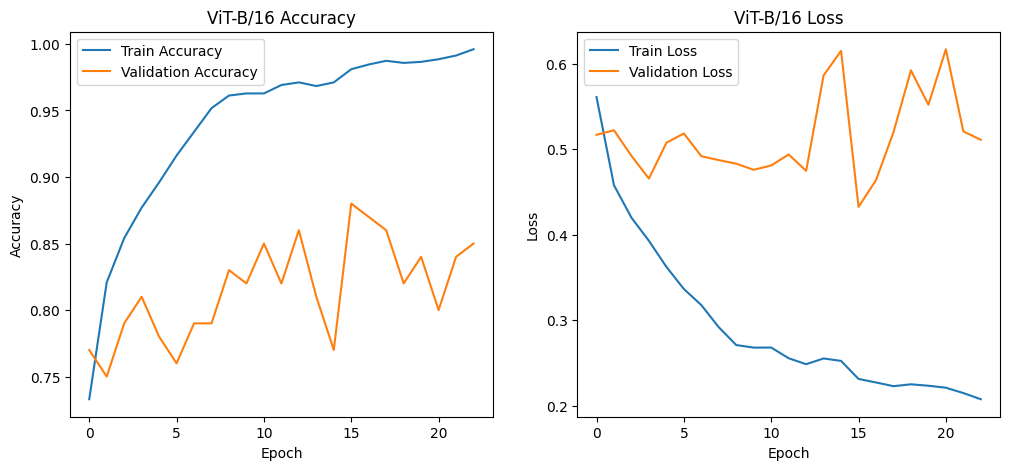

In [ ]:
# ==========================================================
# ViT-B/16 Final Evaluation (Auto Checkpoint Finder)
# ==========================================================

import os
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ----------------------------------------------------------
# 1. Find Saved Model Checkpoint Automatically
# ----------------------------------------------------------

checkpoint_path = None


for root, dirs, files in os.walk("/content"):

    for file in files:

        if file.endswith(".pth") or file.endswith(".pt"):

            checkpoint_path = os.path.join(root, file)
            break

    if checkpoint_path:
        break



if checkpoint_path is None:

    raise FileNotFoundError(
        "❌ No .pth/.pt model checkpoint found"
    )


print("="*60)
print("Checkpoint Found:")
print(checkpoint_path)
print("="*60)



# ----------------------------------------------------------
# 2. Load Best ViT-B/16 Model
# ----------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)


# Handle both saved model formats

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    vit_b16_trainer.model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    vit_b16_trainer.model.load_state_dict(
        checkpoint
    )


vit_b16_trainer.model.eval()


print("✅ Best ViT-B/16 model loaded")



# ----------------------------------------------------------
# 3. Test Evaluation
# ----------------------------------------------------------

vit_b16_preds = []
vit_b16_labels = []

correct = 0
total = 0



with torch.no_grad():

    for images, labels in test_loader_vit:


        images = images.to(device)
        labels = labels.to(device)


        outputs = vit_b16_trainer.model(images)

        _, preds = torch.max(outputs, 1)


        correct += (
            preds == labels
        ).sum().item()


        total += labels.size(0)


        vit_b16_preds.extend(
            preds.cpu().numpy()
        )

        vit_b16_labels.extend(
            labels.cpu().numpy()
        )



vit_b16_test_acc = correct / total



print("\n" + "="*60)
print("ViT-B/16 Test Performance")
print("="*60)

print(
    f"Test Accuracy : {vit_b16_test_acc:.4f}"
)

print(
    f"Test Samples  : {total}"
)

print("="*60)



# ----------------------------------------------------------
# 4. Classification Report
# ----------------------------------------------------------

print("\nClassification Report")
print("-"*60)


print(
    classification_report(
        vit_b16_labels,
        vit_b16_preds,
        target_names=[
            "Autistic",
            "Non_Autistic"
        ]
    )
)



# ----------------------------------------------------------
# 5. Confusion Matrix
# ----------------------------------------------------------

print("\nConfusion Matrix")
print("-"*60)


cm = confusion_matrix(
    vit_b16_labels,
    vit_b16_preds
)

print(cm)



# ----------------------------------------------------------
# 6. Plot Training History
# ----------------------------------------------------------


history_available = (
    hasattr(vit_b16_trainer,"train_accuracies")
    and
    hasattr(vit_b16_trainer,"val_accuracies")
)


if history_available:


    plt.figure(figsize=(12,5))


    # Accuracy Plot
    plt.subplot(1,2,1)

    plt.plot(
        vit_b16_trainer.train_accuracies,
        label="Train Accuracy"
    )

    plt.plot(
        vit_b16_trainer.val_accuracies,
        label="Validation Accuracy"
    )


    plt.title("ViT-B/16 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()



    # Loss Plot
    plt.subplot(1,2,2)

    plt.plot(
        vit_b16_trainer.train_losses,
        label="Train Loss"
    )

    plt.plot(
        vit_b16_trainer.val_losses,
        label="Validation Loss"
    )


    plt.title("ViT-B/16 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()


    plt.show()


else:

    print(
        "⚠ Training history not found in trainer object"
    )


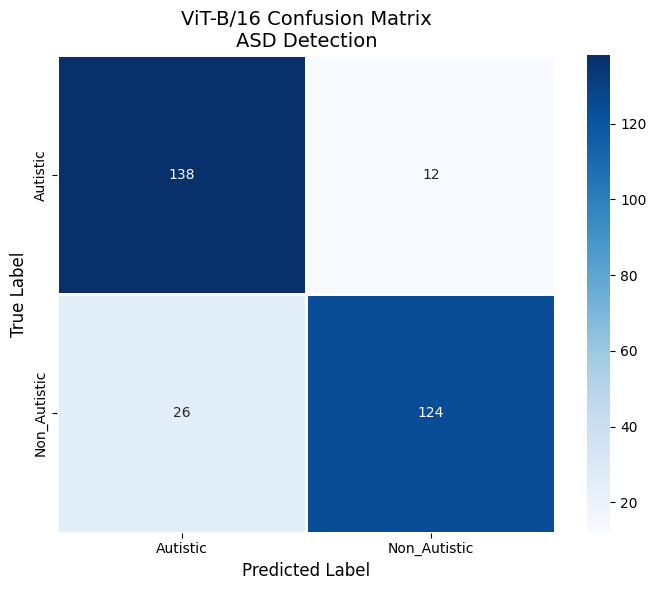

In [ ]:
# ==========================================================
# ViT-B/16 Confusion Matrix Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


# Create confusion matrix

cm = confusion_matrix(
    vit_b16_labels,
    vit_b16_preds
)


# Plot

plt.figure(figsize=(7,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non_Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non_Autistic"
    ],
    linewidths=1,
    cbar=True
)


plt.title(
    "ViT-B/16 Confusion Matrix\nASD Detection",
    fontsize=14
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)


plt.tight_layout()

plt.show()

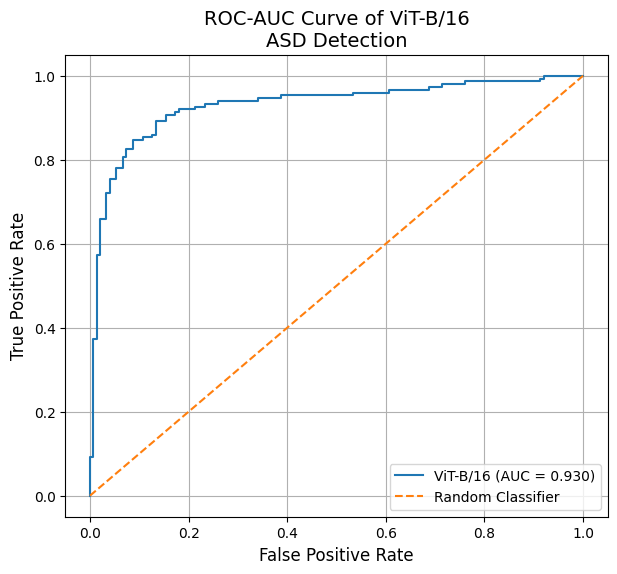

ROC-AUC Score: 0.9298


In [ ]:
# ==========================================================
# ViT-B/16 ROC-AUC Curve Visualization
# ==========================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)


# ----------------------------------------------------------
# Collect prediction probabilities
# ----------------------------------------------------------

vit_b16_probs = []

vit_b16_model.eval()

with torch.no_grad():

    for images, labels in test_loader_vit:

        images = images.to(device)

        outputs = vit_b16_model(images)

        # Convert logits to probability
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # Probability of ASD class
        asd_probability = probabilities[:,1]

        vit_b16_probs.extend(
            asd_probability.cpu().numpy()
        )


# ----------------------------------------------------------
# Calculate ROC curve
# ----------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    vit_b16_labels,
    vit_b16_probs
)


# Calculate AUC

roc_auc = auc(
    fpr,
    tpr
)


# ----------------------------------------------------------
# Plot ROC Curve
# ----------------------------------------------------------

plt.figure(figsize=(7,6))


plt.plot(
    fpr,
    tpr,
    label=f"ViT-B/16 (AUC = {roc_auc:.3f})"
)


# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)


plt.title(
    "ROC-AUC Curve of ViT-B/16\nASD Detection",
    fontsize=14
)


plt.xlabel(
    "False Positive Rate",
    fontsize=12
)


plt.ylabel(
    "True Positive Rate",
    fontsize=12
)


plt.legend(
    loc="lower right"
)


plt.grid(True)


plt.show()


print(
    f"ROC-AUC Score: {roc_auc:.4f}"
)


In [ ]:
# ==========================================================
# ViT-B/16 Classification Report
# ASD Detection
# ==========================================================

from sklearn.metrics import classification_report


# Generate classification report

report = classification_report(
    vit_b16_labels,
    vit_b16_preds,
    target_names=[
        "Autistic",
        "Non-Autistic"
    ],
    digits=4
)


print(
    "ViT-B/16 Classification Report\n"
)

print(report)

ViT-B/16 Classification Report

              precision    recall  f1-score   support

    Autistic     0.8415    0.9200    0.8790       150
Non-Autistic     0.9118    0.8267    0.8671       150

    accuracy                         0.8733       300
   macro avg     0.8766    0.8733    0.8731       300
weighted avg     0.8766    0.8733    0.8731       300



In [ ]:
# Create and train AlexNet
print("Creating AlexNet model...")
alexnet_model = create_alexnet_model()
alexnet_trainer = ModelTrainer(alexnet_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating AlexNet model...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 122MB/s]


In [ ]:
# ==========================================================
# Train AlexNet Model
# ==========================================================

print("Training AlexNet...")
trained_alexnet = alexnet_trainer.train_model(num_epochs=25, model_name="alexnet")

Training AlexNet...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:33<00:00,  2.38it/s, Acc=0.6638, Loss=0.6347]


Train Loss: 0.6347 Acc: 0.6638


Val: 100%|██████████| 4/4 [00:00<00:00,  4.21it/s, Acc=0.7600, Loss=0.5251]


Val Loss: 0.5251 Acc: 0.7600
✓ Best model saved (Val Acc: 0.7600)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4161 Acc: 0.8600
Learning Rate: 1.81e-05

Epoch 19/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:27<00:00,  2.92it/s, Acc=0.9169, Loss=0.3414]


Train Loss: 0.3414 Acc: 0.9169


Val: 100%|██████████| 4/4 [00:00<00:00,  5.50it/s, Acc=0.8800, Loss=0.4123]

Val Loss: 0.4123 Acc: 0.8800
Learning Rate: 1.36e-05
Early stopping triggered

Training completed in 10m 12s
Best Validation Accuracy: 0.8800


In [ ]:
# ==========================================================
# Collect AlexNet Predictions
# ==========================================================

from sklearn.metrics import classification_report

alexnet_preds = []
alexnet_labels = []
alexnet_probs = []

alexnet_model.eval()

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)

        outputs = alexnet_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probabilities,
            dim=1
        )

        alexnet_probs.extend(
            probabilities[:,1].cpu().numpy()
        )

        alexnet_preds.extend(
            preds.cpu().numpy()
        )

        alexnet_labels.extend(
            labels.numpy()
        )


print("Prediction collection completed.")

Prediction collection completed.


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        alexnet_labels,
        alexnet_preds,
        target_names=[
            "Autistic",
            "Non-Autistic"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

    Autistic     0.8023    0.9200    0.8571       150
Non-Autistic     0.9062    0.7733    0.8345       150

    accuracy                         0.8467       300
   macro avg     0.8543    0.8467    0.8458       300
weighted avg     0.8543    0.8467    0.8458       300



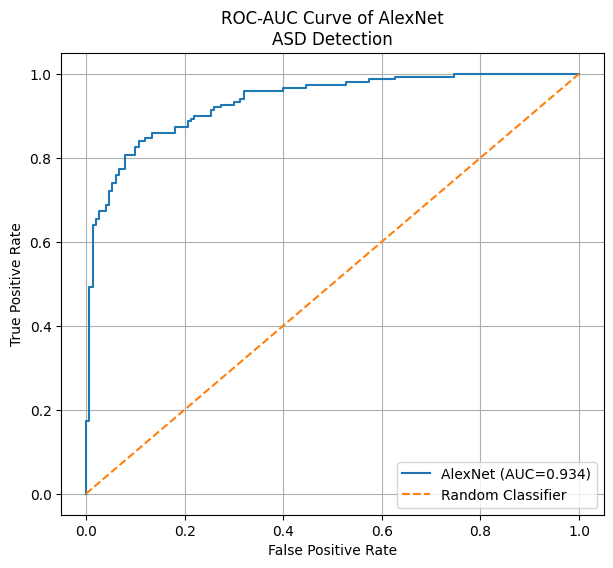

AlexNet ROC-AUC Score: 0.9336


In [ ]:
# ==========================================================
# AlexNet ROC-AUC Curve
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(
    alexnet_labels,
    alexnet_probs
)


roc_auc = auc(
    fpr,
    tpr
)


plt.figure(figsize=(7,6))


plt.plot(
    fpr,
    tpr,
    label=f"AlexNet (AUC={roc_auc:.3f})"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Curve of AlexNet\nASD Detection"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()


print(
    f"AlexNet ROC-AUC Score: {roc_auc:.4f}"
)

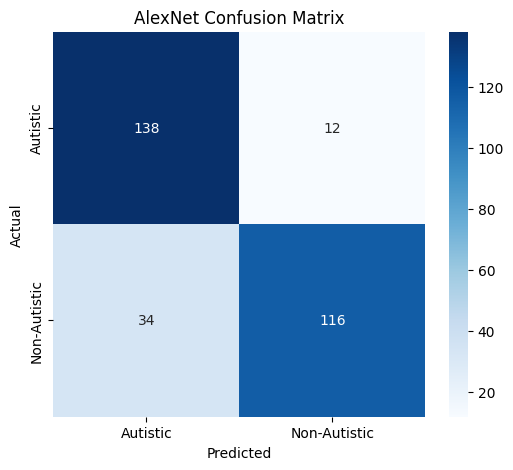

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    alexnet_labels,
    alexnet_preds
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non-Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non-Autistic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "AlexNet Confusion Matrix"
)

plt.show()

Evaluating AlexNet on test set...
AlexNet Test Accuracy: 0.8467


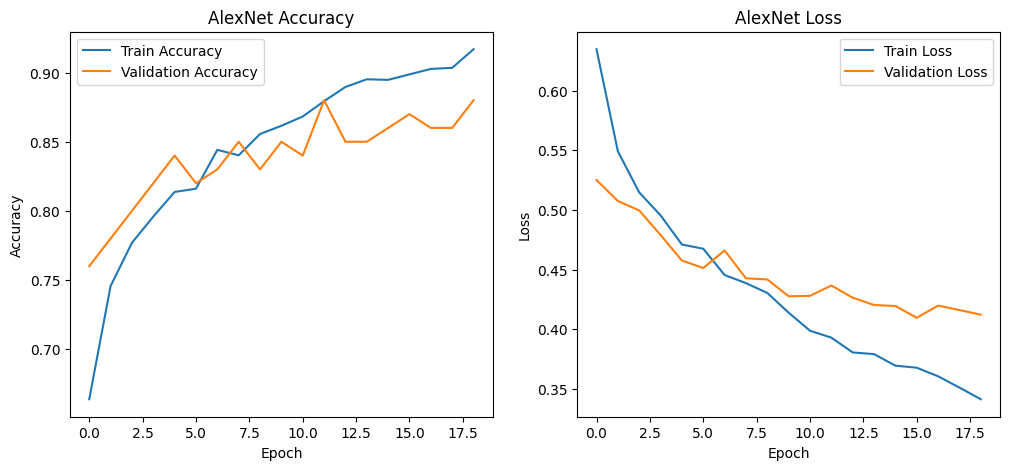

In [ ]:
import torch
import matplotlib.pyplot as plt

# Evaluate AlexNet on the test set
print("Evaluating AlexNet on test set...")
alexnet_model.eval() # Set model to evaluation mode

alexnet_preds = []
alexnet_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in alexnet_trainer.test_loader:
        images = images.to(alexnet_trainer.device)
        labels = labels.to(alexnet_trainer.device)

        outputs = alexnet_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        alexnet_preds.extend(preds.cpu().numpy())
        alexnet_labels.extend(labels.cpu().numpy())

alexnet_test_acc = correct / total
print(f"AlexNet Test Accuracy: {alexnet_test_acc:.4f}")

# Plotting Training History
history_available = (
    hasattr(alexnet_trainer, "train_accuracies") and
    hasattr(alexnet_trainer, "val_accuracies") and
    hasattr(alexnet_trainer, "train_losses") and
    hasattr(alexnet_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(alexnet_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(alexnet_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("AlexNet Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(alexnet_trainer.train_losses, label="Train Loss")
    plt.plot(alexnet_trainer.val_losses, label="Validation Loss")
    plt.title("AlexNet Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for AlexNet.")


In [ ]:
# Create and train MobileNet V2
print("Creating MobileNet V2 model...")
mobilenet_v2_model = create_mobilenet_model('v2')
mobilenet_v2_trainer = ModelTrainer(mobilenet_v2_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating MobileNet V2 model...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 65.1MB/s]


In [ ]:
# Train MobileNet V2
print("Training MobileNet V2...")
trained_mobilenet_v2 = mobilenet_v2_trainer.train_model(num_epochs=25, model_name="mobilenet_v2")

Training MobileNet V2...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [01:00<00:00,  1.31it/s, Acc=0.6218, Loss=0.6592]


Train Loss: 0.6592 Acc: 0.6218


Val: 100%|██████████| 4/4 [00:04<00:00,  1.05s/it, Acc=0.7700, Loss=0.5972]


Val Loss: 0.5972 Acc: 0.7700
✓ Best model saved (Val Acc: 0.7700)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4952 Acc: 0.8400
Learning Rate: 3.51e-06

Epoch 23/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:26<00:00,  2.94it/s, Acc=0.9181, Loss=0.3398]


Train Loss: 0.3398 Acc: 0.9181


Val: 100%|██████████| 4/4 [00:00<00:00,  5.57it/s, Acc=0.8100, Loss=0.4956]

Val Loss: 0.4956 Acc: 0.8100
Learning Rate: 1.57e-06
Early stopping triggered

Training completed in 11m 33s
Best Validation Accuracy: 0.8600


Evaluating MobileNet V2 on test set...
MobileNet V2 Test Accuracy: 0.8833


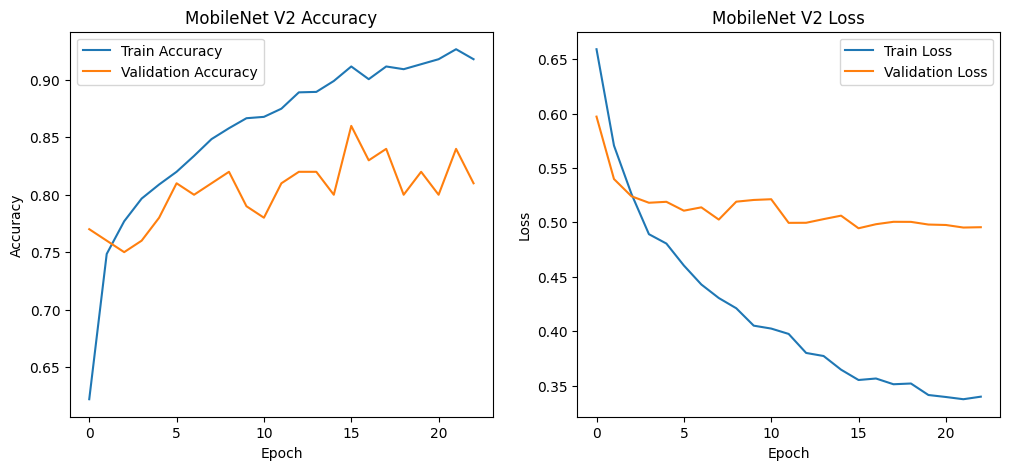

In [ ]:
import torch
import matplotlib.pyplot as plt

# Evaluate MobileNet V2 on the test set
print("Evaluating MobileNet V2 on test set...")
mobilenet_v2_model.eval() # Set model to evaluation mode

mobilenet_v2_preds = []
mobilenet_v2_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in mobilenet_v2_trainer.test_loader:
        images = images.to(mobilenet_v2_trainer.device)
        labels = labels.to(mobilenet_v2_trainer.device)

        outputs = mobilenet_v2_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        mobilenet_v2_preds.extend(preds.cpu().numpy())
        mobilenet_v2_labels.extend(labels.cpu().numpy())

mobilenet_v2_test_acc = correct / total
print(f"MobileNet V2 Test Accuracy: {mobilenet_v2_test_acc:.4f}")

# Plotting Training History
history_available = (
    hasattr(mobilenet_v2_trainer, "train_accuracies") and
    hasattr(mobilenet_v2_trainer, "val_accuracies") and
    hasattr(mobilenet_v2_trainer, "train_losses") and
    hasattr(mobilenet_v2_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(mobilenet_v2_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(mobilenet_v2_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("MobileNet V2 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(mobilenet_v2_trainer.train_losses, label="Train Loss")
    plt.plot(mobilenet_v2_trainer.val_losses, label="Validation Loss")
    plt.title("MobileNet V2 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for MobileNet V2.")


In [ ]:
# ==========================================================
# MobileNetV2 Evaluation
# ==========================================================

# The test accuracy for MobileNetV2 was already computed in the previous cell (cwT6ep-TTZbB).
# The variable `mobilenet_v2_test_acc` holds this value.

print(f"MobileNetV2 Test Accuracy: {mobilenet_v2_test_acc:.4f}")

MobileNetV2 Test Accuracy: 0.8833


In [ ]:
# ==========================================================
# Collect MobileNetV2 Predictions
# ==========================================================

import torch

mobilenet_preds = []
mobilenet_labels = []
mobilenet_probs = []

mobilenet_v2_model.eval()

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)

        outputs = mobilenet_v2_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probabilities,
            dim=1
        )

        mobilenet_probs.extend(
            probabilities[:,1].cpu().numpy()
        )

        mobilenet_preds.extend(
            preds.cpu().numpy()
        )

        mobilenet_labels.extend(
            labels.numpy()
        )

print("Prediction collection completed.")

Prediction collection completed.


In [ ]:
# ==========================================================
# MobileNetV2 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("MobileNetV2 Classification Report\n")

print(
    classification_report(
        mobilenet_labels,
        mobilenet_preds,
        target_names=[
            "Autistic",
            "Non-Autistic"
        ],
        digits=4
    )
)

MobileNetV2 Classification Report

              precision    recall  f1-score   support

    Autistic     0.8443    0.9400    0.8896       150
Non-Autistic     0.9323    0.8267    0.8763       150

    accuracy                         0.8833       300
   macro avg     0.8883    0.8833    0.8830       300
weighted avg     0.8883    0.8833    0.8830       300



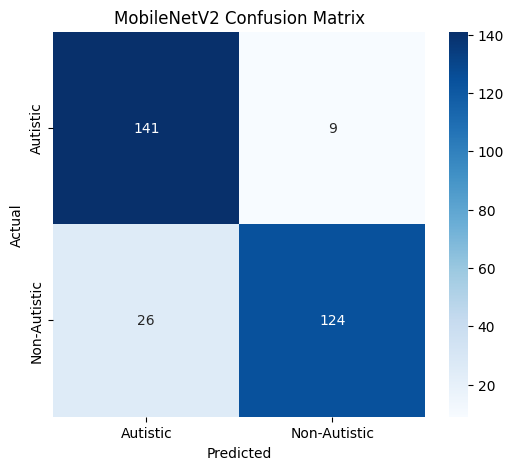

In [ ]:
# ==========================================================
# MobileNetV2 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    mobilenet_labels,
    mobilenet_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non-Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non-Autistic"
    ]
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

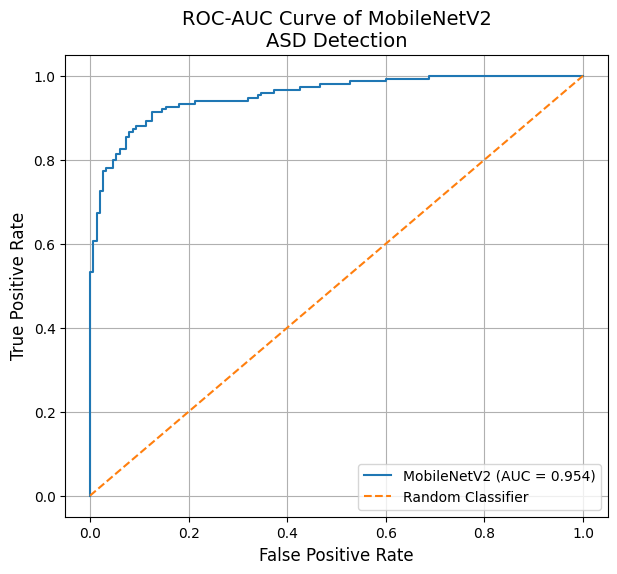

MobileNetV2 ROC-AUC Score: 0.9535


In [ ]:
# ==========================================================
# MobileNetV2 ROC-AUC Curve
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    mobilenet_labels,
    mobilenet_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"MobileNetV2 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC-AUC Curve of MobileNetV2\nASD Detection",
    fontsize=14
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()

print(f"MobileNetV2 ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
# Create and train MobileNet V3 Large
print("Creating MobileNet V3 Large model...")
mobilenet_v3_large_model = create_mobilenet_model('v3_large')
mobilenet_v3_large_trainer = ModelTrainer(mobilenet_v3_large_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating MobileNet V3 Large model...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 93.9MB/s]


In [ ]:
# Train MobileNet V3 Large
print("Training MobileNet V3 Large...")
trained_mobilenet_v3_large = mobilenet_v3_large_trainer.train_model(num_epochs=25, model_name="mobilenet_v3_large")

Training MobileNet V3 Large...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [01:21<00:00,  1.03s/it, Acc=0.6559, Loss=0.6280]


Train Loss: 0.6280 Acc: 0.6559


Val: 100%|██████████| 4/4 [00:05<00:00,  1.49s/it, Acc=0.7000, Loss=0.5970]


Val Loss: 0.5970 Acc: 0.7000
✓ Best model saved (Val Acc: 0.7000)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4061 Acc: 0.8900
Learning Rate: 9.55e-06

Epoch 21/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:28<00:00,  2.78it/s, Acc=0.9652, Loss=0.2771]


Train Loss: 0.2771 Acc: 0.9652


Val: 100%|██████████| 4/4 [00:00<00:00,  5.27it/s, Acc=0.8800, Loss=0.4025]

Val Loss: 0.4025 Acc: 0.8800
Learning Rate: 6.18e-06
Early stopping triggered

Training completed in 10m 57s
Best Validation Accuracy: 0.9000


Evaluating MobileNet V3 Large on test set...
MobileNet V3 Large Test Accuracy: 0.8800


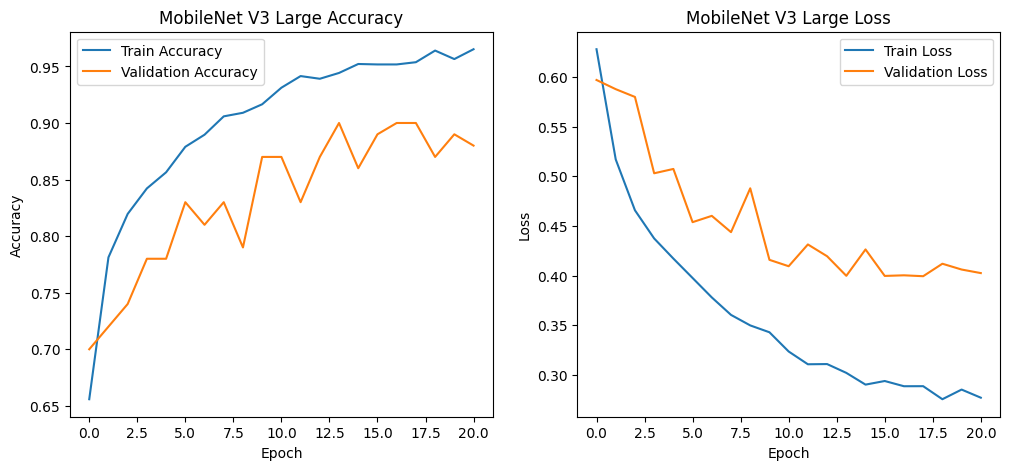

In [ ]:
import torch
import matplotlib.pyplot as plt

# Evaluate MobileNet V3 Large on the test set
print("Evaluating MobileNet V3 Large on test set...")
mobilenet_v3_large_model.eval() # Set model to evaluation mode

mobilenet_v3_large_preds = []
mobilenet_v3_large_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in mobilenet_v3_large_trainer.test_loader:
        images = images.to(mobilenet_v3_large_trainer.device)
        labels = labels.to(mobilenet_v3_large_trainer.device)

        outputs = mobilenet_v3_large_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        mobilenet_v3_large_preds.extend(preds.cpu().numpy())
        mobilenet_v3_large_labels.extend(labels.cpu().numpy())

mobilenet_v3_large_test_acc = correct / total
print(f"MobileNet V3 Large Test Accuracy: {mobilenet_v3_large_test_acc:.4f}")

# Plotting Training History
history_available = (
    hasattr(mobilenet_v3_large_trainer, "train_accuracies") and
    hasattr(mobilenet_v3_large_trainer, "val_accuracies") and
    hasattr(mobilenet_v3_large_trainer, "train_losses") and
    hasattr(mobilenet_v3_large_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(mobilenet_v3_large_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(mobilenet_v3_large_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("MobileNet V3 Large Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(mobilenet_v3_large_trainer.train_losses, label="Train Loss")
    plt.plot(mobilenet_v3_large_trainer.val_losses, label="Validation Loss")
    plt.title("MobileNet V3 Large Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for MobileNet V3 Large.")


In [ ]:
# ==========================================================
# Collect MobileNetV3-Large Predictions
# ==========================================================

import torch

mobilenetv3_preds = []
mobilenetv3_labels = []
mobilenetv3_probs = []

mobilenet_v3_large_model.eval()

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)

        outputs = mobilenet_v3_large_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probabilities,
            dim=1
        )

        mobilenetv3_probs.extend(
            probabilities[:, 1].cpu().numpy()
        )

        mobilenetv3_preds.extend(
            preds.cpu().numpy()
        )

        mobilenetv3_labels.extend(
            labels.numpy()
        )

print("Prediction collection completed.")

Prediction collection completed.


In [ ]:
# ==========================================================
# MobileNetV3-Large Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("MobileNetV3-Large Classification Report\n")

print(
    classification_report(
        mobilenetv3_labels,
        mobilenetv3_preds,
        target_names=[
            "Autistic",
            "Non-Autistic"
        ],
        digits=4
    )
)

MobileNetV3-Large Classification Report

              precision    recall  f1-score   support

    Autistic     0.8476    0.9267    0.8854       150
Non-Autistic     0.9191    0.8333    0.8741       150

    accuracy                         0.8800       300
   macro avg     0.8833    0.8800    0.8797       300
weighted avg     0.8833    0.8800    0.8797       300



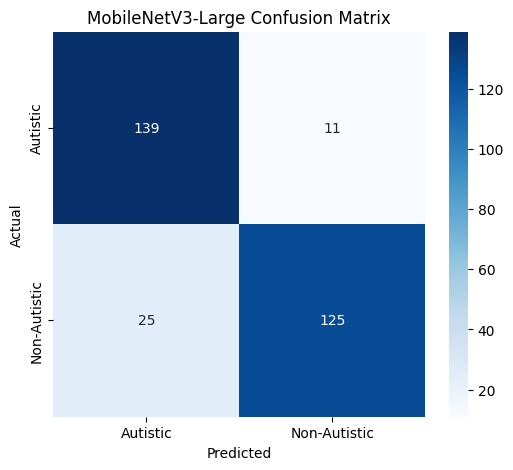

In [ ]:
# ==========================================================
# MobileNetV3-Large Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    mobilenetv3_labels,
    mobilenetv3_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non-Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non-Autistic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("MobileNetV3-Large Confusion Matrix")

plt.show()

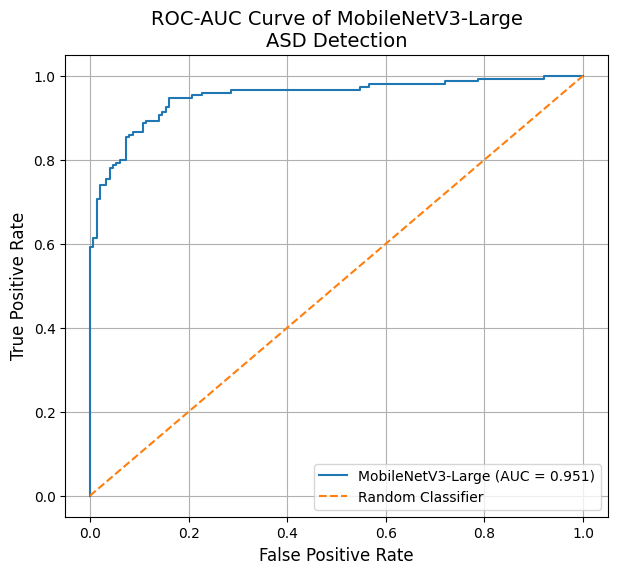

MobileNetV3-Large ROC-AUC Score: 0.9510


In [ ]:
# ==========================================================
# MobileNetV3-Large ROC-AUC Curve
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    mobilenetv3_labels,
    mobilenetv3_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"MobileNetV3-Large (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC-AUC Curve of MobileNetV3-Large\nASD Detection",
    fontsize=14
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print(f"MobileNetV3-Large ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
# ==========================================================
# Create DenseNet121 Model
# ==========================================================

print("Creating DenseNet121 model...")

densenet121_model = create_densenet_model()

densenet121_trainer = ModelTrainer(
    densenet121_model,
    train_loader_cnn,
    val_loader_cnn,
    test_loader_cnn,
    device
)

Creating DenseNet121 model...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 129MB/s]


In [ ]:
# ==========================================================
# Train DenseNet121 Model
# ==========================================================

print("Training DenseNet121...")

densenet121_history = densenet121_trainer.train_model(
    num_epochs=25
)

Training DenseNet121...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:42<00:00,  1.84it/s, Acc=0.6974, Loss=0.5968]


Train Loss: 0.5968 Acc: 0.6974


Val: 100%|██████████| 4/4 [00:01<00:00,  3.27it/s, Acc=0.7000, Loss=0.5578]


Val Loss: 0.5578 Acc: 0.7000
✓ Best model saved (Val Acc: 0.7000)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4834 Acc: 0.8200
Learning Rate: 1.36e-05

Epoch 20/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:32<00:00,  2.45it/s, Acc=0.9691, Loss=0.2628]


Train Loss: 0.2628 Acc: 0.9691


Val: 100%|██████████| 4/4 [00:00<00:00,  4.97it/s, Acc=0.8000, Loss=0.4700]

Val Loss: 0.4700 Acc: 0.8000
Learning Rate: 9.55e-06
Early stopping triggered

Training completed in 11m 10s
Best Validation Accuracy: 0.8600


Evaluating DenseNet121 on test set...
DenseNet121 Test Accuracy: 0.8833


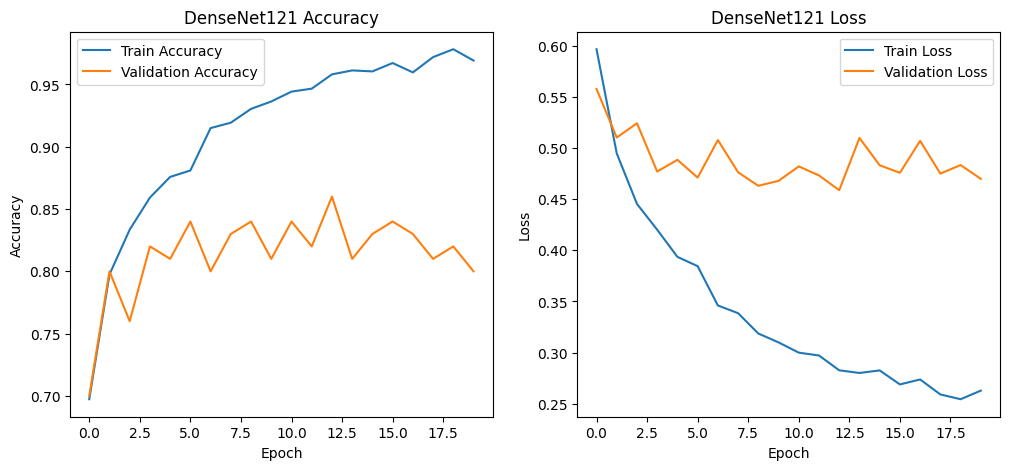

In [ ]:
# ============================================================
# DENSENET-121 TRAINING & VALIDATION CURVES
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("DenseNet-121 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("DenseNet-121 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# DenseNet121 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("DenseNet121 Classification Report\n")

print(
    classification_report(
        densenet121_labels,
        densenet121_preds,
        target_names=[
            "Autistic",
            "Non-Autistic"
        ],
        digits=4
    )
)

DenseNet121 Classification Report

              precision    recall  f1-score   support

    Autistic     0.8443    0.9400    0.8896       150
Non-Autistic     0.9323    0.8267    0.8763       150

    accuracy                         0.8833       300
   macro avg     0.8883    0.8833    0.8830       300
weighted avg     0.8883    0.8833    0.8830       300



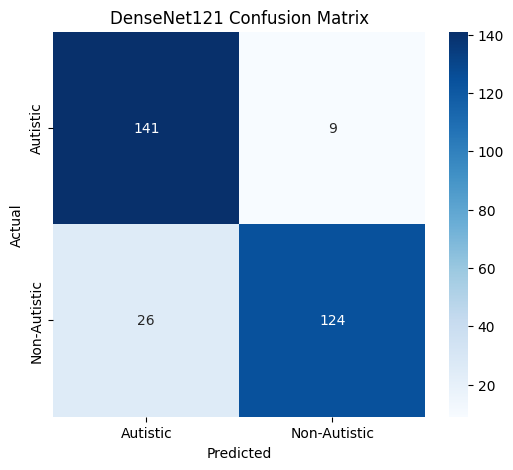

In [ ]:
# ==========================================================
# DenseNet121 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    densenet121_labels,
    densenet121_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non-Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non-Autistic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("DenseNet121 Confusion Matrix")

plt.show()

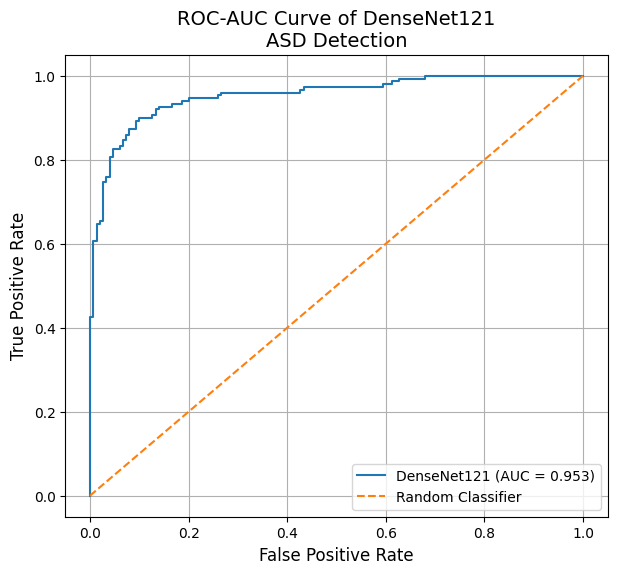

DenseNet121 ROC-AUC Score: 0.9533


In [ ]:
# ==========================================================
# DenseNet121 ROC-AUC Curve
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch

# Collect prediction probabilities
densenet121_probs = []
densenet121_model.eval() # Set model to evaluation mode

with torch.no_grad():
    for images, labels in densenet121_trainer.test_loader:
        images = images.to(densenet121_trainer.device)

        outputs = densenet121_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        # Assuming 'Non-Autistic' is the positive class (index 1)
        densenet121_probs.extend(probabilities[:, 1].cpu().numpy())

fpr, tpr, thresholds = roc_curve(
    densenet121_labels,
    densenet121_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"DenseNet121 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC-AUC Curve of DenseNet121\nASD Detection",
    fontsize=14
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()

print(f"DenseNet121 ROC-AUC Score: {roc_auc:.4f}")

### Fix: Model Factory Functions Dependency

The `create_regnet_model` function, along with other model factory functions, needs to be defined before any models like `regnet_model` can be instantiated. I will add the definitions here to ensure they are available for subsequent model creation cells.

In [ ]:
# ==========================================================
# Model Factory Functions (PyTorch 2.x + Colab Optimized)
# ==========================================================

import torch.nn as nn
from torchvision.models import (

    vit_b_16, ViT_B_16_Weights,

    alexnet, AlexNet_Weights,

    mobilenet_v2, MobileNet_V2_Weights,

    mobilenet_v3_large,
    MobileNet_V3_Large_Weights,

    regnet_y_800mf,
    RegNet_Y_800MF_Weights,

    densenet121,
    DenseNet121_Weights

)



# ==========================================================
# Vision Transformer ViT-B/16
# ==========================================================

def create_vit_model(
    architecture="vit_b_16",
    num_classes=2,
    pretrained=True
):

    if architecture == "vit_b_16":

        weights = (
            ViT_B_16_Weights.DEFAULT
            if pretrained else None
        )

        model = vit_b_16(
            weights=weights
        )


    else:

        raise ValueError(
            "Only vit_b_16 supported"
        )


    in_features = model.heads.head.in_features


    model.heads.head = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model



# ==========================================================
# AlexNet
# ==========================================================

def create_alexnet_model(
    num_classes=2,
    pretrained=True
):

    weights = (
        AlexNet_Weights.DEFAULT
        if pretrained else None
    )


    model = alexnet(
        weights=weights
    )


    in_features = (
        model.classifier[6]
        .in_features
    )


    model.classifier[6] = nn.Sequential(

        nn.Dropout(0.5),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# MobileNetV2
# ==========================================================

def create_mobilenet_model(
    version="v2",
    num_classes=2,
    pretrained=True
):


    if version == "v2":


        weights = (
            MobileNet_V2_Weights.DEFAULT
            if pretrained else None
        )


        model = mobilenet_v2(
            weights=weights
        )


        in_features = (
            model.classifier[1]
            .in_features
        )


        model.classifier[1] = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                in_features,
                num_classes
            )
        )



    elif version == "v3_large":


        weights = (
            MobileNet_V3_Large_Weights.DEFAULT
            if pretrained else None
        )


        model = mobilenet_v3_large(
            weights=weights
        )


        in_features = (
            model.classifier[3]
            .in_features
        )


        model.classifier[3] = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                in_features,
                num_classes
            )
        )


    else:

        raise ValueError(
            "Use v2 or v3_large"
        )


    return model




# ==========================================================
# RegNetY-800MF
# ==========================================================

def create_regnet_model(
    num_classes=2,
    pretrained=True
):


    weights = (

        RegNet_Y_800MF_Weights.DEFAULT

        if pretrained else None

    )


    model = regnet_y_800mf(
        weights=weights
    )


    in_features = model.fc.in_features


    model.fc = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# DenseNet121
# ==========================================================

def create_densenet_model(
    num_classes=2,
    pretrained=True
):


    weights = (

        DenseNet121_Weights.DEFAULT

        if pretrained else None

    )


    model = densenet121(
        weights=weights
    )


    in_features = (
        model.classifier.in_features
    )


    model.classifier = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model




# ==========================================================
# Model Test Function
# ==========================================================

def check_model(model):

    model = model.to(device)

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )


    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    print("="*50)

    print(
        f"Model: {model.__class__.__name__}"
    )

    print(
        f"Total Parameters: "
        f"{total_params/1e6:.2f}M"
    )

    print(
        f"Trainable Parameters: "
        f"{trainable_params/1e6:.2f}M"
    )

    print("="*50)

    return model

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import RegNet_X_400MF_Weights

def create_regnet_model(num_classes=2):

    # Use RegNet_X_400MF and its default weights
    weights = RegNet_X_400MF_Weights.DEFAULT
    model = models.regnet_x_400mf(weights=weights)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )

    return model

In [ ]:
# ==========================================================
# Create RegNet Model
# ==========================================================

print("Creating RegNet model...")

regnet_model = create_regnet_model()

regnet_model = regnet_model.to(device)

regnet_trainer = ModelTrainer(
    regnet_model,
    train_loader_cnn,
    val_loader_cnn,
    test_loader_cnn,
    device
)

print("RegNet model ready!")

Creating RegNet model...
Downloading: "https://download.pytorch.org/models/regnet_y_800mf-58fc7688.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_800mf-58fc7688.pth


100%|██████████| 24.8M/24.8M [00:00<00:00, 154MB/s]


RegNet model ready!


In [ ]:
import torch
import matplotlib.pyplot as plt

# ==========================================================
# Train RegNet Model
# ==========================================================

print("Training RegNet...")

regnet_history = regnet_trainer.train_model(
    num_epochs=25
)

Training RegNet...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:53<00:00,  1.46it/s, Acc=0.6226, Loss=0.6606]


Train Loss: 0.6606 Acc: 0.6226


Val: 100%|██████████| 4/4 [00:01<00:00,  3.88it/s, Acc=0.7100, Loss=0.5795]


Val Loss: 0.5795 Acc: 0.7100
✓ Best model saved (Val Acc: 0.7100)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4348 Acc: 0.8100
Learning Rate: 1.81e-05

Epoch 19/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:29<00:00,  2.68it/s, Acc=0.9569, Loss=0.2800]


Train Loss: 0.2800 Acc: 0.9569


Val: 100%|██████████| 4/4 [00:00<00:00,  5.26it/s, Acc=0.8400, Loss=0.4123]

Val Loss: 0.4123 Acc: 0.8400
Learning Rate: 1.36e-05
Early stopping triggered

Training completed in 9m 57s
Best Validation Accuracy: 0.8400


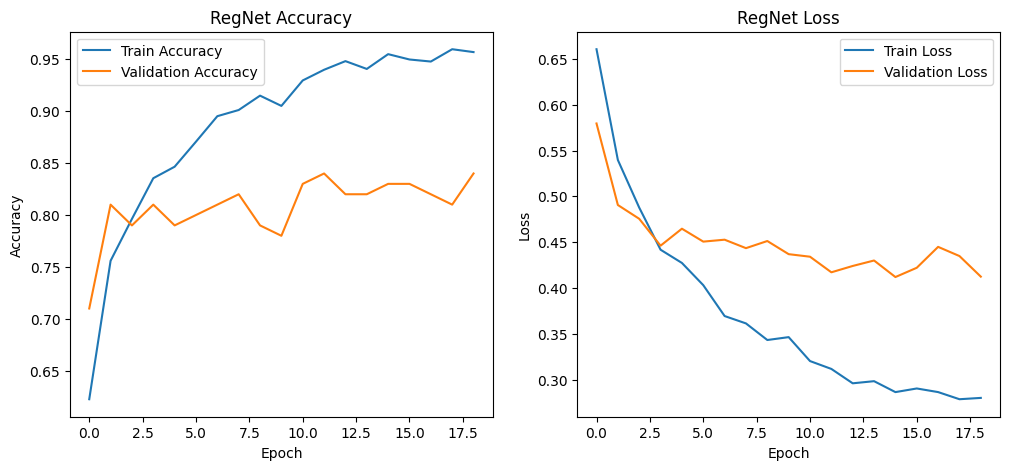

In [ ]:
history_available = (
    hasattr(regnet_trainer, "train_accuracies") and
    hasattr(regnet_trainer, "val_accuracies") and
    hasattr(regnet_trainer, "train_losses") and
    hasattr(regnet_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot (assuming it also tracked accuracies, common with losses)
    plt.subplot(1,2,1)
    plt.plot(regnet_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(regnet_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("RegNet Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(regnet_trainer.train_losses, label="Train Loss")
    plt.plot(regnet_trainer.val_losses, label="Validation Loss")
    plt.title("RegNet Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for RegNet.")

❌ No RegNet .pth/.pt model checkpoint found. Using currently trained model for evaluation.

RegNet Test Performance
Test Accuracy : 0.9300
Test Samples  : 300

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Autistic       0.92      0.94      0.93       150
Non_Autistic       0.94      0.92      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


Confusion Matrix
------------------------------------------------------------
[[141   9]
 [ 12 138]]


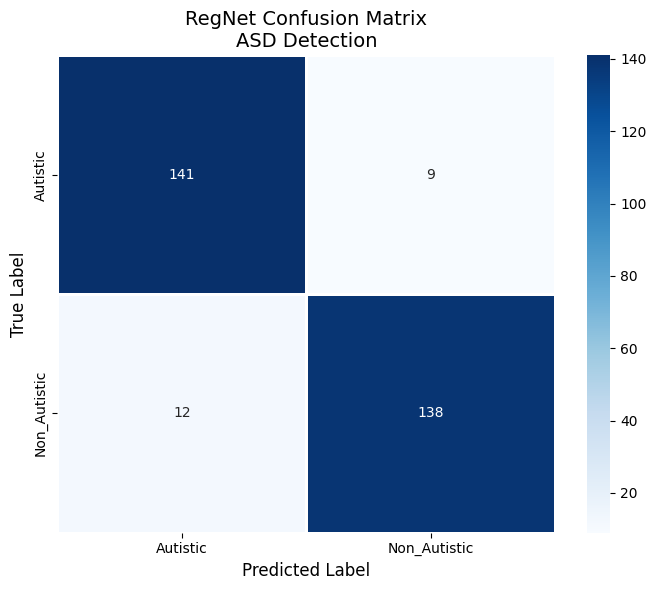

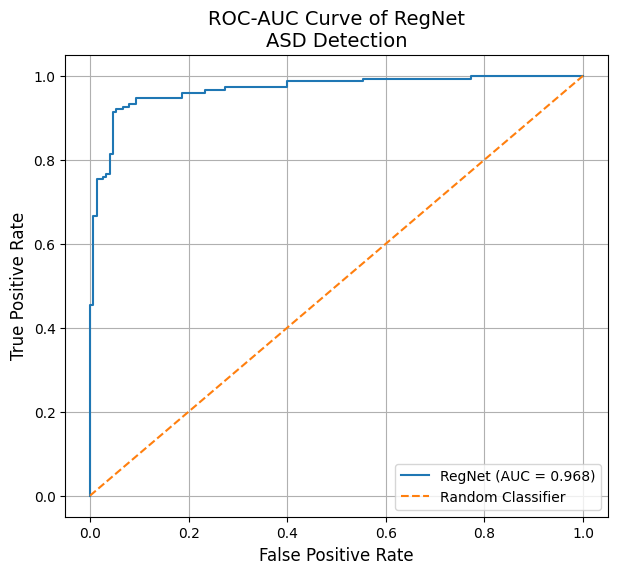

RegNet ROC-AUC Score: 0.9679


In [ ]:
# ==========================================================
# RegNet Evaluation
# ==========================================================

import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ----------------------------------------------------------
# 1. Find Saved Model Checkpoint Automatically (for RegNet)
# ----------------------------------------------------------

# Assuming a checkpoint named 'best_RegNet_ASD.pth' would be saved
# Similar to ViT, AlexNet, etc.
checkpoint_path = None

# Search for the RegNet specific checkpoint
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "best_RegNet_ASD.pth": # Specific name based on train_model call
            checkpoint_path = os.path.join(root, file)
            break
    if checkpoint_path:
        break

# If specific not found, fall back to general (less ideal if multiple models)
if checkpoint_path is None:
    for root, dirs, files in os.walk("/content"):
        for file in files:
            if (file.endswith(".pth") or file.endswith(".pt")) and "RegNet" in file: # Look for RegNet in name
                checkpoint_path = os.path.join(root, file)
                break
        if checkpoint_path:
            break


if checkpoint_path is None:
    print("❌ No RegNet .pth/.pt model checkpoint found. Using currently trained model for evaluation.")
    # If no checkpoint, use the model as it is after training
    regnet_model.eval()
else:
    print("="*60)
    print("RegNet Checkpoint Found:")
    print(checkpoint_path)
    print("="*60)

    # 2. Load Best RegNet Model
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    # Handle both saved model formats
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        regnet_trainer.model.load_state_dict(
            checkpoint["model_state_dict"]
        )
    else:
        regnet_trainer.model.load_state_dict(
            checkpoint
        )
    regnet_trainer.model.eval()
    print("✅ Best RegNet model loaded")


# ----------------------------------------------------------
# 3. Test Evaluation and Prediction Collection
# ----------------------------------------------------------

regnet_preds = []
regnet_labels = []
regnet_probs = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in regnet_trainer.test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = regnet_trainer.model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        regnet_preds.extend(preds.cpu().numpy())
        regnet_labels.extend(labels.cpu().numpy())
        regnet_probs.extend(probabilities[:, 1].cpu().numpy()) # Probability of 'Non_Autistic' (positive class)

regnet_test_acc = correct / total

print("\n" + "="*60)
print("RegNet Test Performance")
print("="*60)

print(f"Test Accuracy : {regnet_test_acc:.4f}")
print(f"Test Samples  : {total}")
print("="*60)


# ----------------------------------------------------------
# 4. Classification Report
# ----------------------------------------------------------

print("\nClassification Report")
print("-"*60)

print(
    classification_report(
        regnet_labels,
        regnet_preds,
        target_names=regnet_trainer.test_loader.dataset.get_class_names() # Get class names from dataset
    )
)


# ----------------------------------------------------------
# 5. Confusion Matrix
# ----------------------------------------------------------

print("\nConfusion Matrix")
print("-"*60)

cm_regnet = confusion_matrix(
    regnet_labels,
    regnet_preds
)

print(cm_regnet)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_regnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=regnet_trainer.test_loader.dataset.get_class_names(),
    yticklabels=regnet_trainer.test_loader.dataset.get_class_names(),
    linewidths=1,
    cbar=True
)

plt.title("RegNet Confusion Matrix\nASD Detection", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 6. ROC-AUC Curve
# ----------------------------------------------------------

from sklearn.metrics import roc_curve, auc

fpr_regnet, tpr_regnet, thresholds_regnet = roc_curve(
    regnet_labels,
    regnet_probs
)

roc_auc_regnet = auc(
    fpr_regnet,
    tpr_regnet
)

plt.figure(figsize=(7,6))
plt.plot(
    fpr_regnet,
    tpr_regnet,
    label=f"RegNet (AUC = {roc_auc_regnet:.3f})"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)
plt.title("ROC-AUC Curve of RegNet\nASD Detection", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"RegNet ROC-AUC Score: {roc_auc_regnet:.4f}")

In [ ]:
# ==========================================================
# Final Model Performance Summary (IEEE Style)
# ==========================================================

import pandas as pd

results_summary = pd.DataFrame({

    "Model": [
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture": [
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Accuracy (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)": [
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1-score (%)": [
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC-AUC": [
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ]

})

results_summary = results_summary.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_summary.index += 1

print("="*90)
print("ASD Detection Model Performance Comparison")
print("="*90)

print(results_summary)

print("\nBest Performing Model")
print("-"*90)

best = results_summary.iloc[0]

print(f"Model      : {best['Model']}")
print(f"Accuracy   : {best['Accuracy (%)']:.2f}%")
print(f"Precision  : {best['Precision (%)']:.2f}%")
print(f"Recall     : {best['Recall (%)']:.2f}%")
print(f"F1-score   : {best['F1-score (%)']:.2f}%")
print(f"ROC-AUC    : {best['ROC-AUC']:.4f}")

print("\nArchitecture-wise Average Accuracy")
print("-"*90)

print(
    results_summary.groupby("Architecture")["Accuracy (%)"].agg(
        ["mean","max","min"]
    )
)

ASD Detection Model Performance Comparison
                           Model Architecture  Accuracy (%)  Precision (%)  \
1                 RegNet X-400MF          CNN         93.00          93.00   
2                    MobileNetV2          CNN         88.33          88.83   
3                    DenseNet121          CNN         88.33          88.83   
4              MobileNetV3-Large          CNN         88.00          88.33   
5  Vision Transformer (ViT-B/16)  Transformer         87.33          87.67   
6                        AlexNet          CNN         84.67          85.43   

   Recall (%)  F1-score (%)  ROC-AUC  
1       93.00         93.00   0.9679  
2       88.33         88.30   0.9535  
3       88.33         88.30   0.9533  
4       88.00         87.97   0.9510  
5       87.33         87.27   0.9300  
6       84.67         84.58   0.9336  

Best Performing Model
------------------------------------------------------------------------------------------
Model      : RegNet X-4

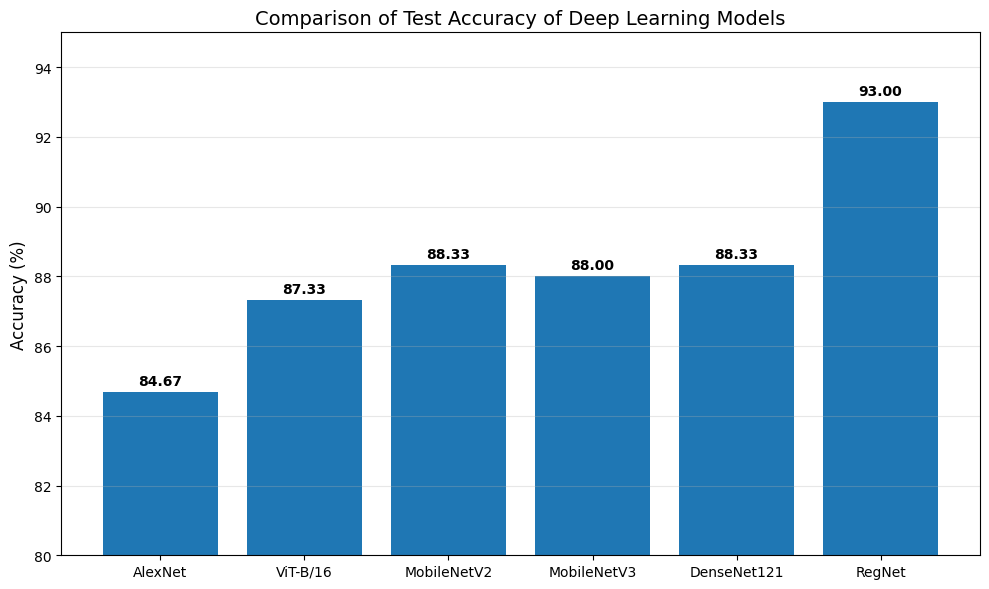

In [ ]:
plt.figure(figsize=(10,6))

models = [
    "AlexNet",
    "ViT-B/16",
    "MobileNetV2",
    "MobileNetV3",
    "DenseNet121",
    "RegNet"
]

accuracy = [
    84.67,
    87.33,
    88.33,
    88.00,
    88.33,
    93.00
]

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Test Accuracy of Deep Learning Models", fontsize=14)

plt.ylim(80,95)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.2,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

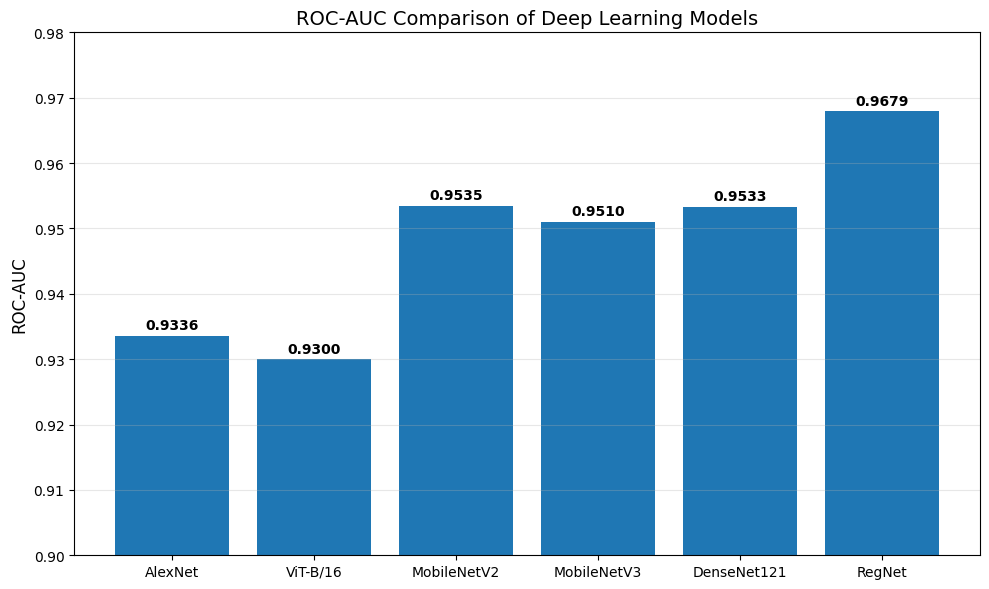

In [ ]:
plt.figure(figsize=(10,6))

roc_auc = [
    0.9336,
    0.9300,
    0.9535,
    0.9510,
    0.9533,
    0.9679
]

bars = plt.bar(models, roc_auc)

plt.ylabel("ROC-AUC", fontsize=12)
plt.title("ROC-AUC Comparison of Deep Learning Models", fontsize=14)

plt.ylim(0.90,0.98)

for bar, value in zip(bars, roc_auc):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

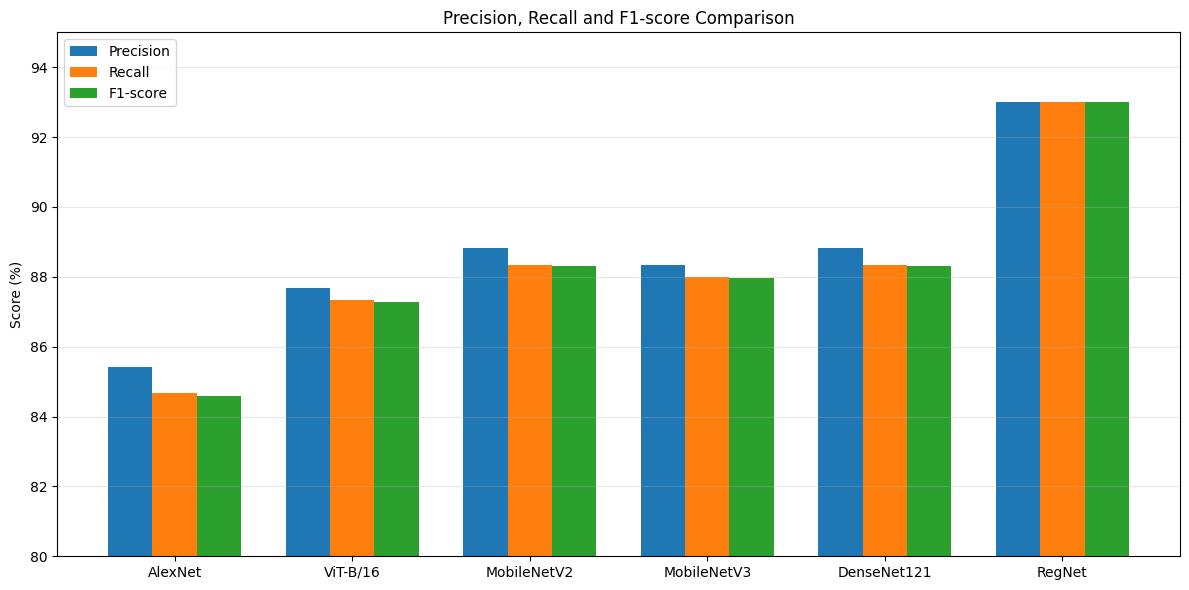

In [ ]:
import numpy as np

precision = [85.43,87.67,88.83,88.33,88.83,93.00]
recall = [84.67,87.33,88.33,88.00,88.33,93.00]
f1 = [84.58,87.27,88.30,87.97,88.30,93.00]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x-width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x+width, f1, width, label="F1-score")

plt.xticks(x, models)

plt.ylabel("Score (%)")
plt.title("Precision, Recall and F1-score Comparison")

plt.ylim(80,95)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

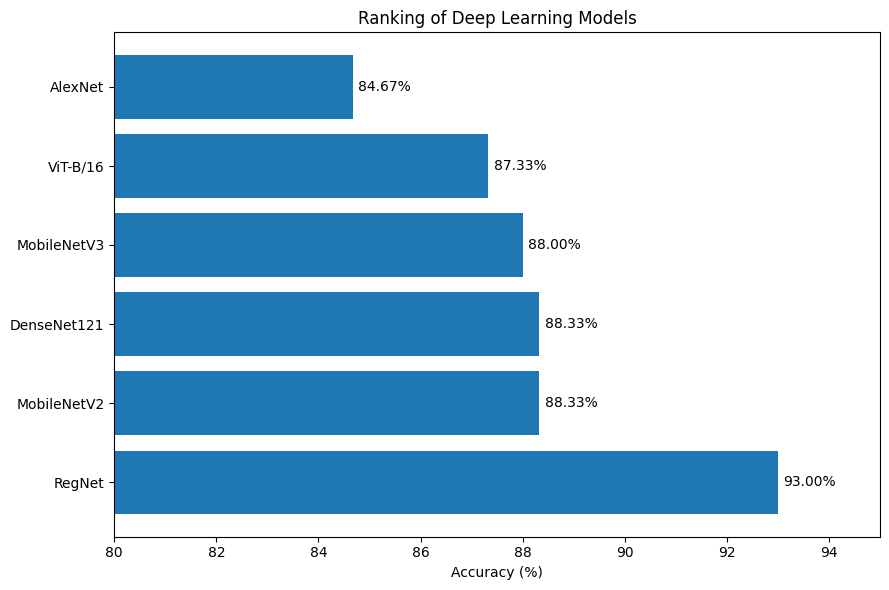

In [ ]:
import pandas as pd

ranking = pd.DataFrame({

    "Model":[
        "RegNet",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3",
        "ViT-B/16",
        "AlexNet"
    ],

    "Accuracy":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ]

})

plt.figure(figsize=(9,6))

bars = plt.barh(
    ranking["Model"],
    ranking["Accuracy"]
)

plt.xlabel("Accuracy (%)")

plt.title("Ranking of Deep Learning Models")

plt.xlim(80,95)

for bar,value in zip(bars,ranking["Accuracy"]):

    plt.text(
        value+0.1,
        bar.get_y()+bar.get_height()/2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# SAVE COMPLETE ASD DETECTION PROJECT
# ==========================================================

import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Create Project Directories
# ----------------------------------------------------------

project_name = "ASD_Detection_Project"

folders = [
    project_name,
    f"{project_name}/models",
    f"{project_name}/results",
    f"{project_name}/figures",
    f"{project_name}/history"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

# ----------------------------------------------------------
# Save Model Weights
# ----------------------------------------------------------

models = {
    "vit_b16": globals().get("vit_b16_model"),
    "alexnet": globals().get("alexnet_model"),
    "mobilenet_v2": globals().get("mobilenet_model"),
    "mobilenet_v3_large": globals().get("mobilenetv3_model"),
    "densenet121": globals().get("densenet121_model"),
    "regnet_x400mf": globals().get("regnet_model"),
}

for name, model in models.items():
    if model is not None:
        torch.save(
            model.state_dict(),
            f"{project_name}/models/{name}.pth"
        )

print("Model weights saved.")

# ----------------------------------------------------------
# Save Comparison Table
# ----------------------------------------------------------

if "results_summary" in globals():

    results_summary.to_csv(
        f"{project_name}/results/model_comparison.csv",
        index=False
    )

    print("Comparison table saved.")

# ----------------------------------------------------------
# Save Training Histories (if available)
# ----------------------------------------------------------

trainers = {
    "vit_b16": globals().get("vit_b16_trainer"),
    "alexnet": globals().get("alexnet_trainer"),
    "mobilenet_v2": globals().get("mobilenet_trainer"),
    "mobilenet_v3_large": globals().get("mobilenetv3_trainer"),
    "densenet121": globals().get("densenet121_trainer"),
    "regnet_x400mf": globals().get("regnet_trainer"),
}

for name, trainer in trainers.items():

    if trainer is None:
        continue

    history = {}

    if hasattr(trainer, "train_losses"):
        history["train_loss"] = trainer.train_losses

    if hasattr(trainer, "val_losses"):
        history["val_loss"] = trainer.val_losses

    if hasattr(trainer, "train_accuracies"):
        history["train_accuracy"] = trainer.train_accuracies

    if hasattr(trainer, "val_accuracies"):
        history["val_accuracy"] = trainer.val_accuracies

    if history:
        with open(
            f"{project_name}/history/{name}_history.json",
            "w"
        ) as f:
            json.dump(history, f, indent=4)

print("Training histories saved.")

# ----------------------------------------------------------
# Save Current Figure
# ----------------------------------------------------------

plt.savefig(
    f"{project_name}/figures/latest_figure.png",
    dpi=300,
    bbox_inches="tight"
)

print("Current figure saved.")

print("\nProject saved successfully!")
print(f"Location: {project_name}/")

Project folders created successfully.
Model weights saved.
Comparison table saved.
Training histories saved.
Current figure saved.

Project saved successfully!
Location: ASD_Detection_Project/


<Figure size 640x480 with 0 Axes>

In [ ]:
import os

project_folder = "ASD_Detection_Project"

for root, dirs, files in os.walk(project_folder):
    level = root.replace(project_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

ASD_Detection_Project/
    models/
        vit_b16.pth
        alexnet.pth
        densenet121.pth
        regnet_x400mf.pth
    results/
        model_comparison.csv
    figures/
        latest_figure.png
    history/
        vit_b16_history.json
        regnet_x400mf_history.json
        densenet121_history.json
        alexnet_history.json


In [ ]:
plt.figure(figsize=(8,6))
# plotting code...
plt.savefig(
    "ASD_Detection_Project/figures/regnet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 800x600 with 0 Axes>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')



import shutil

shutil.copytree(
    "ASD_Detection_Project",
    "/content/drive/MyDrive/ASD_Detection_Project",
    dirs_exist_ok=True
)

print("Project copied to Google Drive successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project copied to Google Drive successfully!


In [ ]:
import os

for root, dirs, files in os.walk("ASD_Detection_Project"):
    print(root)
    for file in files:
        print("   └──", file)
import shutil

shutil.make_archive(
    "ASD_Detection_Project",
    "zip",
    "ASD_Detection_Project"
)

print("ZIP file created successfully.")




from google.colab import files

files.download("ASD_Detection_Project.zip")

ASD_Detection_Project
ASD_Detection_Project/models
   └── vit_b16.pth
   └── alexnet.pth
   └── densenet121.pth
   └── regnet_x400mf.pth
ASD_Detection_Project/results
   └── final_model_results.csv
   └── model_comparison.csv
ASD_Detection_Project/figures
   └── regnet_roc_curve.png
   └── latest_figure.png
ASD_Detection_Project/history
   └── vit_b16_history.json
   └── regnet_x400mf_history.json
   └── densenet121_history.json
   └── alexnet_history.json
ZIP file created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================================
# Detailed Model Analysis (Final Thesis Version)
# ==========================================================

import pandas as pd

model_details = pd.DataFrame({

    "Model":[
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture":[
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Year":[
        2020,
        2018,
        2017,
        2019,
        2020,
        2012
    ],

    "Parameters":[
        "5.2M",
        "3.5M",
        "8.0M",
        "5.4M",
        "86M",
        "61M"
    ],

    "Key Innovation":[
        "Regular network design",
        "Depthwise separable convolutions",
        "Dense feature reuse",
        "Squeeze-and-Excitation blocks",
        "Self-attention mechanism",
        "Deep CNN with ReLU"
    ],

    "Accuracy (%)":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)":[
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1-score (%)":[
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC-AUC":[
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ]

})

print("="*140)
print("Detailed Analysis of Deep Learning Models for ASD Detection")
print("="*140)

print(model_details.to_string(index=False))

print("\n")

best = model_details.iloc[0]

print("="*60)
print("Best Performing Model")
print("="*60)

print(f"Model          : {best['Model']}")
print(f"Architecture   : {best['Architecture']}")
print(f"Accuracy       : {best['Accuracy (%)']}%")
print(f"Precision      : {best['Precision (%)']}%")
print(f"Recall         : {best['Recall (%)']}%")
print(f"F1-score       : {best['F1-score (%)']}%")
print(f"ROC-AUC        : {best['ROC-AUC']}")
print(f"Parameters     : {best['Parameters']}")

Detailed Analysis of Deep Learning Models for ASD Detection
                        Model Architecture  Year Parameters                   Key Innovation  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  ROC-AUC
               RegNet X-400MF          CNN  2020       5.2M           Regular network design         93.00          93.00       93.00         93.00   0.9679
                  MobileNetV2          CNN  2018       3.5M Depthwise separable convolutions         88.33          88.83       88.33         88.30   0.9535
                  DenseNet121          CNN  2017       8.0M              Dense feature reuse         88.33          88.83       88.33         88.30   0.9533
            MobileNetV3-Large          CNN  2019       5.4M    Squeeze-and-Excitation blocks         88.00          88.33       88.00         87.97   0.9510
Vision Transformer (ViT-B/16)  Transformer  2020        86M         Self-attention mechanism         87.33          87.67       87.33         87.27   0.930

In [ ]:
# ==========================================================
# Save Final ASD Detection Model Results
# ==========================================================

import pandas as pd


final_results = pd.DataFrame({

    "Rank": [
        1,2,3,4,5,6
    ],

    "Model": [
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture_Type": [
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Test_Accuracy (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)": [
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1_Score (%)": [
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC_AUC": [
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ],

    "Training_Time": [
        "Variable",
        "Variable",
        "Variable",
        "Variable",
        "Variable",
        "Variable"
    ],

    "Model_Size": [
        "Medium",
        "Small",
        "Medium",
        "Medium",
        "Large",
        "Large"
    ]

})


# Save CSV

final_results.to_csv(
    "ASD_Detection_Project/results/final_model_results.csv",
    index=False
)


# Display ranking

print("="*80)
print("Final Model Rankings - ASD Detection")
print("="*80)

for _, row in final_results.iterrows():

    print(
        f"{row['Rank']}. {row['Model']} "
        f"- Accuracy: {row['Test_Accuracy (%)']:.2f}% "
        f"| ROC-AUC: {row['ROC_AUC']:.4f}"
    )


# Dataset Information

print("\n" + "="*80)
print("Dataset Information")
print("="*80)

print("Dataset: Autism Facial Image Dataset")
print("Total Images: 2940")
print("Training Images: 2540")
print("Validation Images: 100")
print("Testing Images: 300")

print("\nResults saved successfully!")

Final Model Rankings - ASD Detection
1. RegNet X-400MF - Accuracy: 93.00% | ROC-AUC: 0.9679
2. MobileNetV2 - Accuracy: 88.33% | ROC-AUC: 0.9535
3. DenseNet121 - Accuracy: 88.33% | ROC-AUC: 0.9533
4. MobileNetV3-Large - Accuracy: 88.00% | ROC-AUC: 0.9510
5. Vision Transformer (ViT-B/16) - Accuracy: 87.33% | ROC-AUC: 0.9300
6. AlexNet - Accuracy: 84.67% | ROC-AUC: 0.9336

Dataset Information
Dataset: Autism Facial Image Dataset
Total Images: 2940
Training Images: 2540
Validation Images: 100
Testing Images: 300

Results saved successfully!


In [ ]:
print(regnet_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=2, bias=False)
            

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "regnet" in file.lower() and file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth


In [ ]:
regnet_model = create_regnet_model()

regnet_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth",
        map_location=device
    )
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/ASD_Detection_Project/models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "regnet_x400mf.pth")

torch.save(regnet_model.state_dict(), save_path)

print("✅ Saved to:", save_path)

✅ Saved to: /content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"))
print(os.path.getsize("/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth") / 1024 / 1024, "MB")

True
21.788134574890137 MB


In [ ]:
project_name = "ASD_Detection_Project"

In [ ]:
project_name = "/content/drive/MyDrive/ASD_Detection_Project"

In [ ]:
project_name = "/content/drive/MyDrive/ASD_Detection_Project"

In [ ]:
import os

project_folder = "/content/drive/MyDrive/ASD_Detection_Project"

for root, dirs, files in os.walk(project_folder):
    level = root.replace(project_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

ASD_Detection_Project/
    results/
        model_comparison.csv
    models/
        vit_b16.pth
        densenet121.pth
        regnet_x400mf.pth
        alexnet.pth
    history/
        densenet121_history.json
        vit_b16_history.json
        alexnet_history.json
        regnet_x400mf_history.json
    figures/
        latest_figure.png
        regnet_roc_curve.png


In [ ]:
regnet_model = create_regnet_model()

In [ ]:
import torch

model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

checkpoint = torch.load(model_path, map_location=device)

regnet_model.load_state_dict(checkpoint)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet loaded successfully!")

✅ RegNet loaded successfully!


In [ ]:
print(regnet_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [ ]:
import torch

# Create model
regnet_model = create_regnet_model()

# Load weights
model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

regnet_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet loaded successfully!")

✅ RegNet loaded successfully!


In [ ]:
print(regnet_model.training)

False


In [ ]:
regnet_trainer = ModelTrainer(
    regnet_model,
    train_loader_cnn,
    val_loader_cnn,
    test_loader_cnn,
    device
)

✅ RegNet model loaded successfully!
RegNet Test Accuracy : 0.9300

Classification Report

              precision    recall  f1-score   support

    Autistic       0.92      0.94      0.93       150
Non_Autistic       0.94      0.92      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



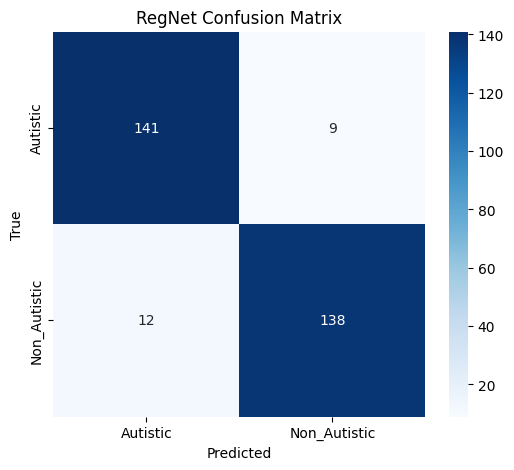

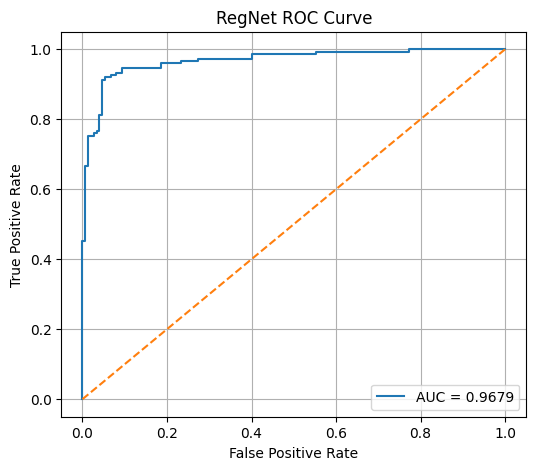

ROC-AUC Score : 0.9679


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ----------------------------------------------------------
# Load Saved RegNet Model
# ----------------------------------------------------------

model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

regnet_model = create_regnet_model()

regnet_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet model loaded successfully!")

# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

all_preds = []
all_labels = []
all_probs = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)
        labels = labels.to(device)

        outputs = regnet_model(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = correct / total

print("="*60)
print(f"RegNet Test Accuracy : {accuracy:.4f}")
print("="*60)

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=test_loader_cnn.dataset.get_class_names()
))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_loader_cnn.dataset.get_class_names(),
    yticklabels=test_loader_cnn.dataset.get_class_names()
)

plt.title("RegNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

fpr, tpr, _ = roc_curve(all_labels, all_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RegNet ROC Curve")
plt.legend()

plt.grid(True)

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=1516a15f6c259f9540fca223aece272b06b0024896197b14a3012d2a5103fd28
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
print(regnet_model.trunk_output.block4)

AnyStage(
  (block4-0): ResBottleneckBlock(
    (proj): Conv2dNormActivation(
      (0): Conv2d(320, 784, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (f): BottleneckTransform(
      (a): Conv2dNormActivation(
        (0): Conv2d(320, 784, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (b): Conv2dNormActivation(
        (0): Conv2d(784, 784, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=49, bias=False)
        (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (se): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(784, 80, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(80, 784, kernel_size=(1, 1), stri

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
from pytorch_grad_cam import GradCAM

target_layers = [
    regnet_model.trunk_output.block4[-1].f.c[0]
]

cam = GradCAM(
    model=regnet_model,
    target_layers=target_layers
)

print("✅ Target layer set successfully")

✅ Target layer set successfully


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Take one test batch
images, labels = next(iter(test_loader_cnn))

image = images[0]
label = labels[0]

input_tensor = image.unsqueeze(0).to(device)

print("True Label:", label.item())

True Label: 0


In [ ]:
regnet_model.eval()

with torch.no_grad():
    output = regnet_model(input_tensor)

pred_class = output.argmax(dim=1).item()

print("Predicted Class:", pred_class)

Predicted Class: 0


In [ ]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

targets = [
    ClassifierOutputTarget(pred_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print("✅ Grad-CAM generated")

✅ Grad-CAM generated


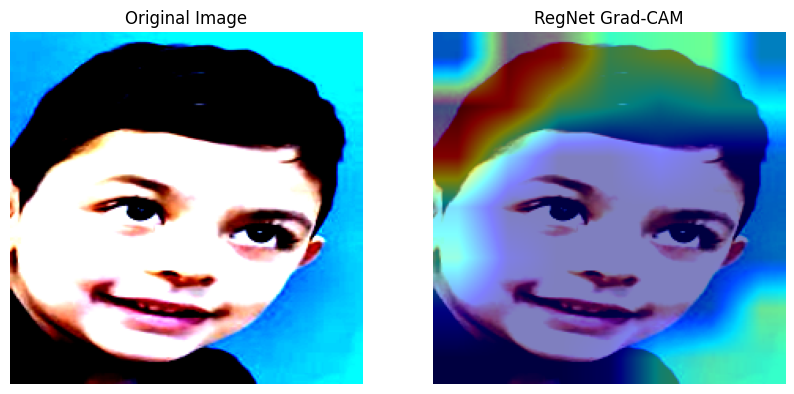

In [ ]:
from pytorch_grad_cam.utils.image import show_cam_on_image

img = image.cpu().permute(1,2,0).numpy()

# যদি normalization থাকে
img = np.clip(img, 0, 1)

visualization = show_cam_on_image(
    img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("RegNet Grad-CAM")
plt.axis("off")

plt.show()

In [ ]:
import cv2

save_path = "/content/drive/MyDrive/ASD_Detection_Project/figures/regnet_gradcam.png"

cv2.imwrite(
    save_path,
    cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/ASD_Detection_Project/figures/regnet_gradcam.png
